## 📑 Project Sections

### 🔹 1. Data Setup
- **Imports & Load Data**
---
### 🔹 2. Exploratory Data Analysis (EDA)
- **Target Distribution, Time-Series & Correlation**
- **Seasonal Patterns, Outliers & Multicollinearity**
---
### 🔹 3. Preprocessing & Feature Engineering
- **Data Cleaning & Transformation**
- **Feature Engineering**
- *(Focused on BOD Prediction)*
---
### 🔹 4. Modeling: BOD Prediction
#### 🌳 Random Forest
- **Baseline Training & Evaluation**
#### ⚡ XGBoost
- **Training & Evaluation**
#### 🔍 SHAP Analysis
- **Interpretability of XGBoost (COD Model)**
---
### 🔹 5. Anomaly Detection
#### 🌲 Isolation Forest
- **Model Implementation & Detection**
#### 🧠 LSTM Autoencoder
- **Deep Learning-Based Detection**
---
### 🔹 6. Model Comparison
- **Isolation Forest vs LSTM Autoencoder**
---
### 🔹 7. Validation & Evaluation
#### 🧪 BOD-Focused Anomaly Validation
- **Domain-Specific Validation**
#### 📊 Formal Metrics
- **Linear Baseline**
- **Model Performance Comparison**

##  Imports & Load Data:

In [109]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler

import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.ensemble import IsolationForest

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, RepeatVector,
                                     TimeDistributed, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
df = pd.read_csv('Data-Melbourne_F.csv')

In [7]:
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
   avg_outflow  avg_inflow  total_grid    Am    BOD     COD      TN     T  \
0        2.941       2.589      175856  27.0  365.0   730.0  60.378  19.3   
1        2.936       2.961      181624  25.0  370.0   740.0  60.026  17.1   
2        2.928       3.225      202016  42.0  418.0   836.0  64.522  16.8   
3        2.928       3.354      207547  36.0  430.0   850.0  63.000  14.6   
4        2.917       3.794      202824  46.0  508.0  1016.0  65.590  13.4   

     TM    Tm  SLP   H    PP    VV     V    VM    VG  year  month  day  
0  25.1  12.6  0.0  56  1.52  10.0  26.9  53.5  79.5  2014      1    1  
1  23.6  12.3  0.0  63  0.00  10.0  14.4  27.8   0.0  2014      1    2  
2  27.2   8.8  0.0  47  0.25  10.0  31.9  61.1  77.8  2014      1    5  
3  19.9  11.1  0.0  49  0.00  10.0  27.0  38.9  53.5  2014      1    6  
4  19.1   8.0  0.0  65  0.00  10.0  20.6  35.2  53.5  2014      1    7  


In [8]:
print(f"Dataset Shape: {df.shape}")
print("\n--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- Statistical Summary ---")
df.describe().round(3)

Dataset Shape: (1382, 20)

--- Column Names & Data Types ---
avg_outflow    float64
avg_inflow     float64
total_grid       int64
Am             float64
BOD            float64
COD            float64
TN             float64
T              float64
TM             float64
Tm             float64
SLP            float64
H                int64
PP             float64
VV             float64
V              float64
VM             float64
VG             float64
year             int64
month            int64
day              int64
dtype: object

--- Statistical Summary ---


,avg_outflow,avg_inflow,total_grid,Am,BOD,COD,TN,T,TM,Tm,SLP,H,PP,VV,V,VM,VG,year,month,day
count,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000
mean,3.931,4.506,275159.089,39.222,382.062,845.960,62.741,15.037,20.531,10.037,3.675,63.559,0.218,9.102,19.483,35.381,29.184,2016.258,6.185,15.585
std,1.229,1.440,44640.534,7.762,85.996,145.417,3.571,5.398,7.097,4.657,61.010,14.534,1.307,16.323,7.137,11.626,31.366,1.583,3.411,8.741
min,0.000,2.589,116638.000,13.000,140.000,360.000,40.000,0.000,0.000,-2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2014.000,1.000,1.000
25%,3.074,3.643,246435.750,34.000,330.000,751.250,61.396,10.800,15.000,6.800,0.000,55.000,0.000,8.400,14.400,27.800,0.000,2015.000,3.000,8.000
50%,3.701,4.162,275808.000,39.000,360.000,845.000,62.957,14.300,19.200,9.600,0.000,66.000,0.000,10.000,18.100,33.500,0.000,2016.000,6.000,15.000
75%,4.499,4.848,305703.750,44.000,422.980,920.000,64.366,18.575,25.200,13.000,0.000,74.000,0.000,10.000,23.300,42.400,57.600,2018.000,9.000,23.000
max,7.920,18.968,398328.000,93.000,850.000,1700.000,92.000,35.500,43.500,28.500,1022.000,97.000,18.030,512.000,49.100,83.500,107.600,2019.000,12.000,31.000


In [9]:
print("\n--- Missing Values Per Column ---")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")


--- Missing Values Per Column ---
No missing values found.


## EDA : Target Distribution, Time-Series & Correlation

In [10]:
warnings.filterwarnings('ignore')

In [11]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120


# Creating a proper datetime column for time-series plots
df['date'] = pd.to_datetime(
    df[['year', 'month', 'day']].rename(
        columns={'year': 'year', 'month': 'month', 'day': 'day'}
    ),
    errors='coerce'
)

# For time-series ordering
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

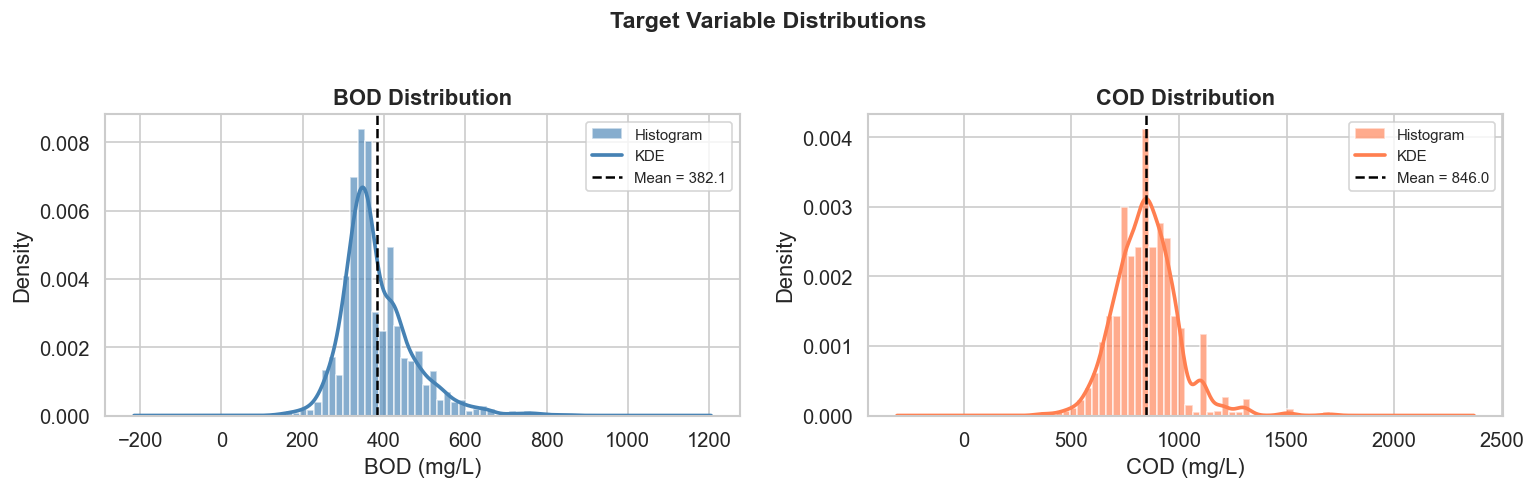

In [12]:
#  BOD & COD Distribution (Histograms + KDE) 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, color in zip(axes, ['BOD', 'COD'], ['steelblue', 'coral']):
    ax.hist(df[col].dropna(), bins=40, color=color, alpha=0.65,
            edgecolor='white', density=True, label='Histogram')
    df[col].dropna().plot.kde(ax=ax, color=color, linewidth=2.2, label='KDE')
    ax.axvline(df[col].mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Mean = {df[col].mean():.1f}')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(f'{col} (mg/L)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Target Variable Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_01_target_distributions.png', bbox_inches='tight')
plt.show()

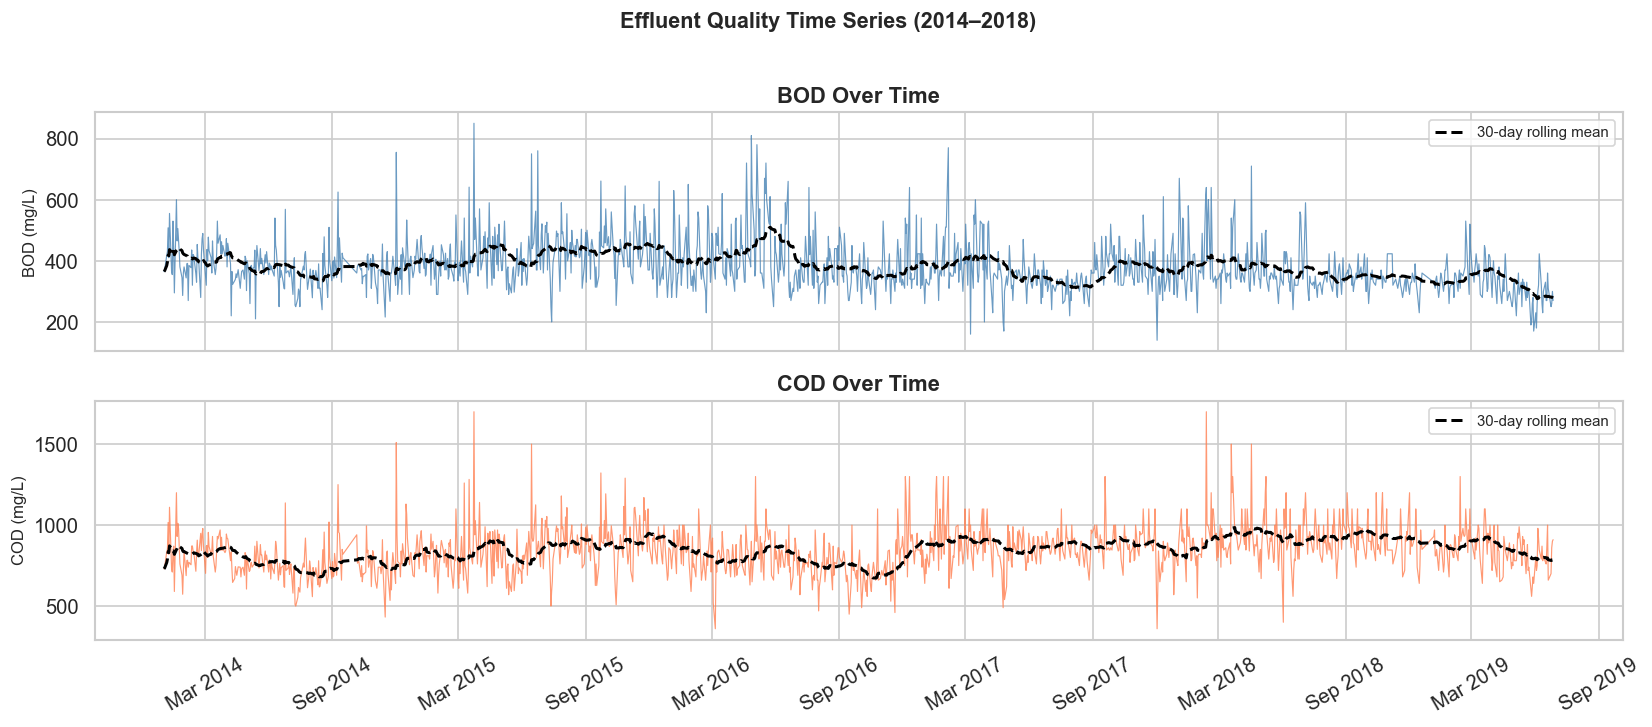

In [13]:
# BOD & COD Time-Series 
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, col, color in zip(axes, ['BOD', 'COD'], ['steelblue', 'coral']):
    ax.plot(df['date'], df[col], color=color, linewidth=0.7, alpha=0.8)
    # 30-day rolling mean to visualise trend
    ax.plot(df['date'], df[col].rolling(30, min_periods=1).mean(),
            color='black', linewidth=1.8, linestyle='--', label='30-day rolling mean')
    ax.set_ylabel(f'{col} (mg/L)', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_title(f'{col} Over Time', fontweight='bold')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30)
plt.suptitle('Effluent Quality Time Series (2014–2018)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_02_timeseries_BOD_COD.png', bbox_inches='tight')
plt.show()

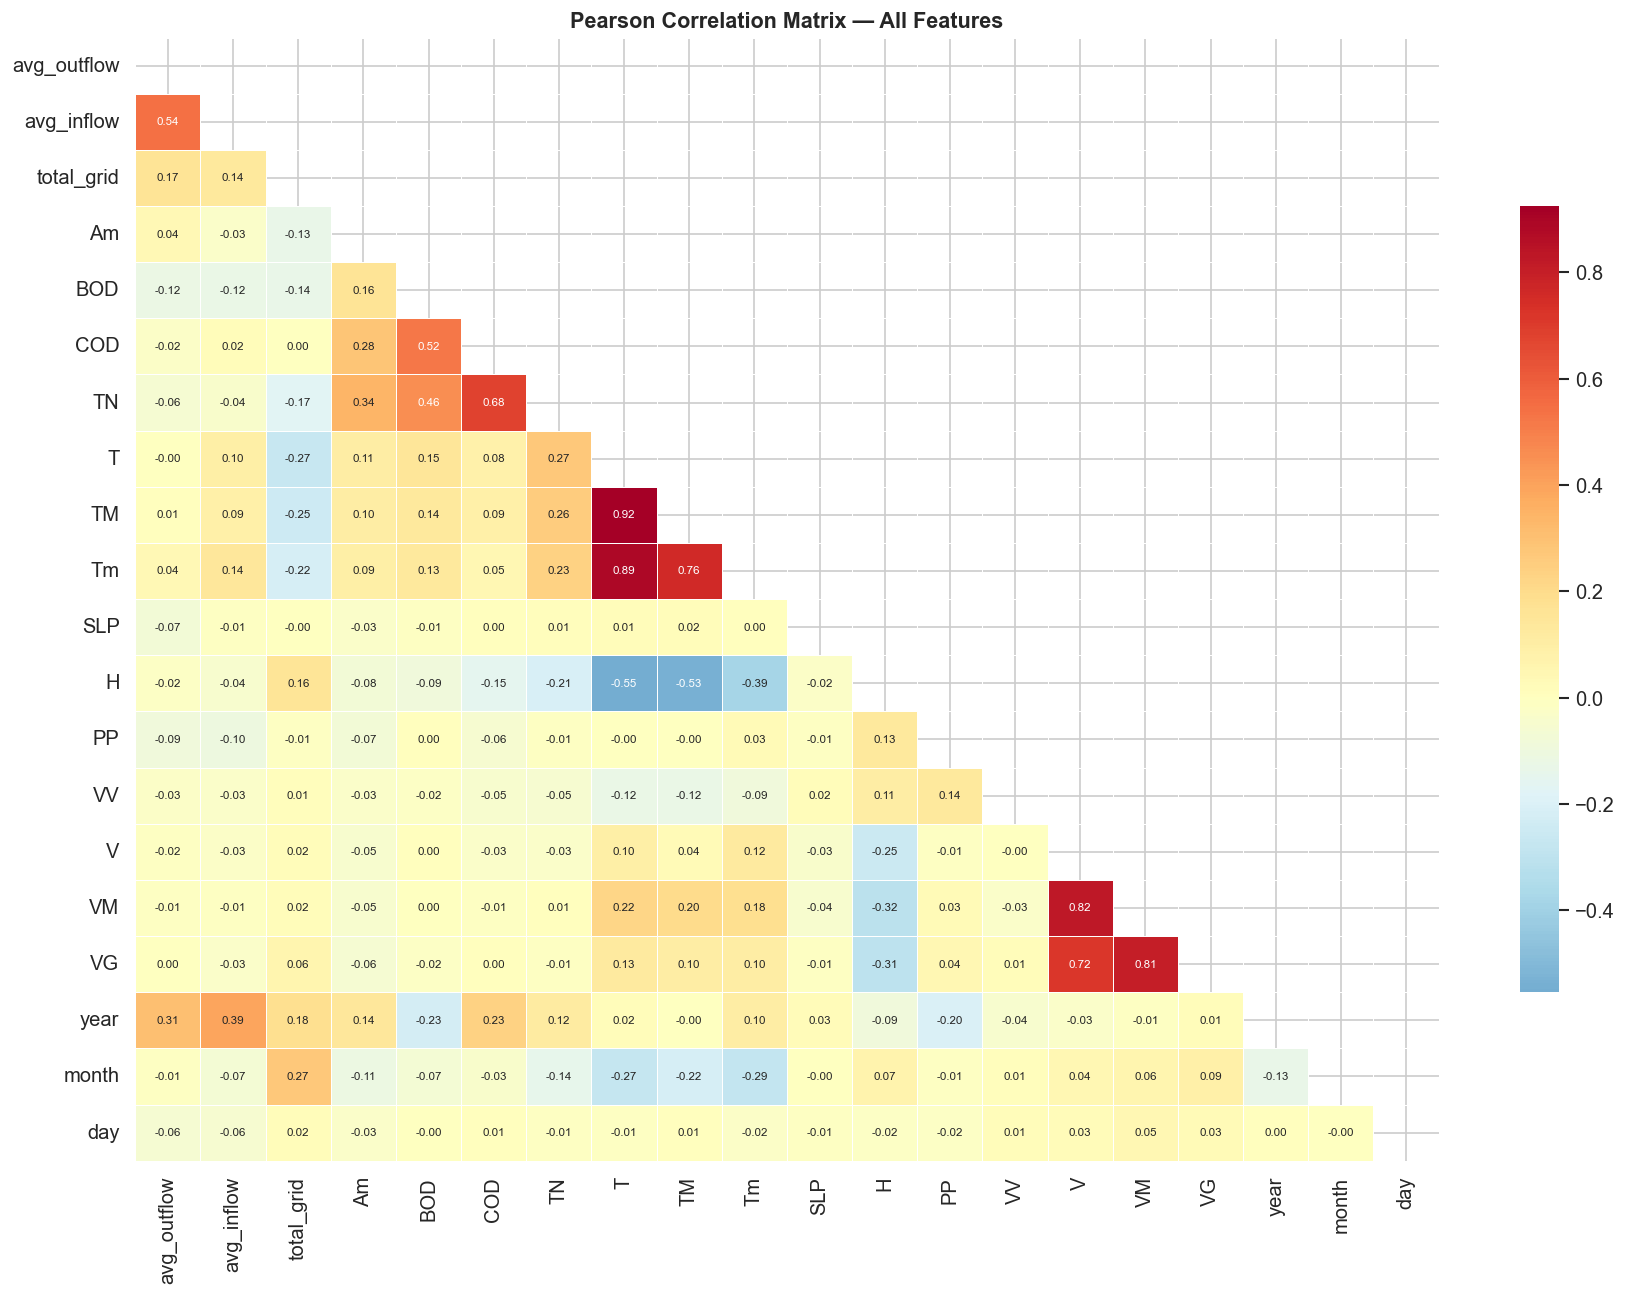

In [14]:
#  Pearson Correlation Heatmap (all numeric features) 
# Excluding date and the raw year/month/day (date encodes them already)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Keeping year/month/day in heatmap asd they carry seasonal signal
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(15, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
    center=0, linewidths=0.4, annot_kws={'size': 7},
    cbar_kws={'shrink': 0.7}, ax=ax
)
ax.set_title('Pearson Correlation Matrix — All Features', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [15]:
# Top correlations with BOD and COD 
print("\n--- Top Correlations with BOD ---")
print(corr_matrix['BOD'].drop(['BOD', 'COD']).abs()
      .sort_values(ascending=False).head(10).to_string())

print("\n--- Top Correlations with COD ---")
print(corr_matrix['COD'].drop(['BOD', 'COD']).abs()
      .sort_values(ascending=False).head(10).to_string())


--- Top Correlations with BOD ---
TN             0.455843
year           0.228753
Am             0.164753
T              0.150706
TM             0.137368
total_grid     0.136945
Tm             0.133025
avg_inflow     0.121364
avg_outflow    0.115811
H              0.087240

--- Top Correlations with COD ---
TN       0.681225
Am       0.284552
year     0.231927
H        0.152655
TM       0.090018
T        0.083946
PP       0.055335
Tm       0.052716
VV       0.050351
month    0.034368


## EDA : Seasonal Patterns, Outliers & Multicollinearity

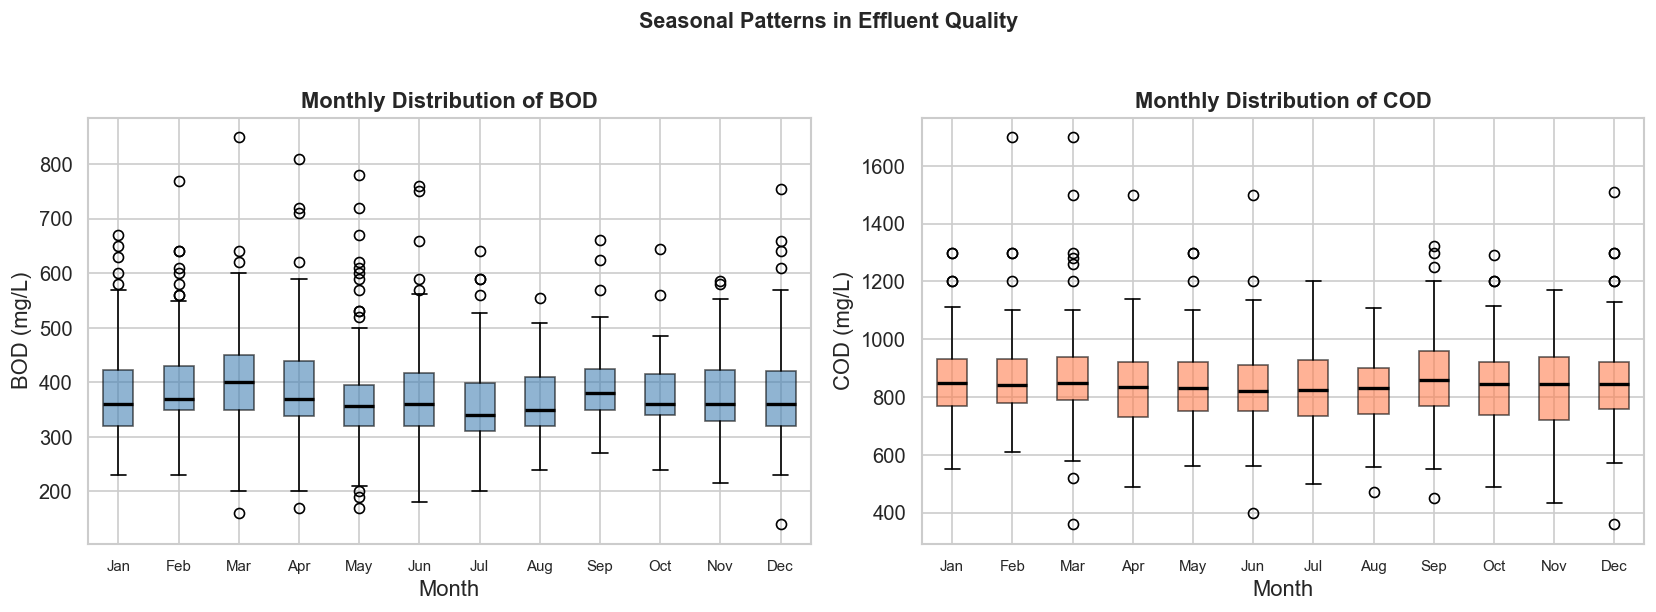

In [16]:
# Monthly Boxplots of BOD & COD (seasonal pattern)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes, ['BOD', 'COD'], ['steelblue', 'coral']):
    # Group by month and plot
    data_by_month = [df[df['month'] == m][col].dropna().values
                     for m in range(1, 13)]
    bp = ax.boxplot(data_by_month, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xticklabels(month_labels, fontsize=9)
    ax.set_xlabel('Month')
    ax.set_ylabel(f'{col} (mg/L)')
    ax.set_title(f'Monthly Distribution of {col}', fontweight='bold')

plt.suptitle('Seasonal Patterns in Effluent Quality', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_04_seasonal_boxplots.png', bbox_inches='tight')
plt.show()

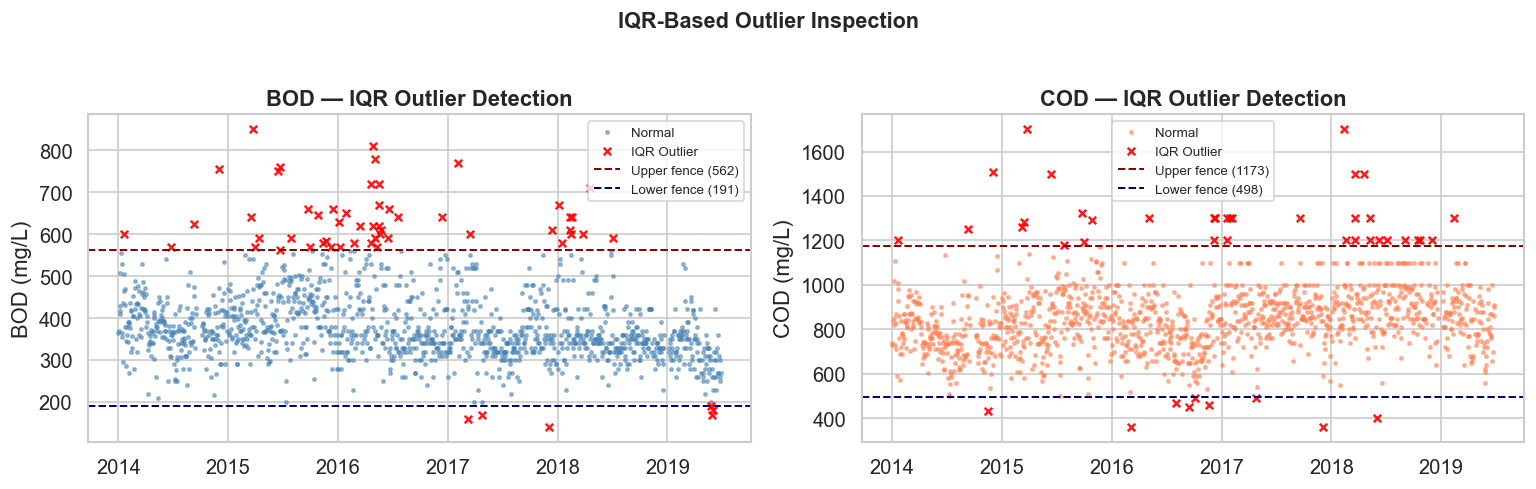

In [17]:
# IQR-Based Outlier Flagging for BOD & COD 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

outlier_report = {}
for ax, col, color in zip(axes, ['BOD', 'COD'], ['steelblue', 'coral']):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    is_outlier = (df[col] < lower) | (df[col] > upper)
    outlier_report[col] = {
        'count': is_outlier.sum(),
        'lower_fence': round(lower, 2),
        'upper_fence': round(upper, 2),
        'pct': round(100 * is_outlier.sum() / len(df), 2)
    }

    # Scatter: normal vs outlier
    ax.scatter(df.loc[~is_outlier, 'date'], df.loc[~is_outlier, col],
               s=4, alpha=0.5, color=color, label='Normal')
    ax.scatter(df.loc[is_outlier, 'date'], df.loc[is_outlier, col],
               s=20, alpha=0.9, color='red', marker='x', label='IQR Outlier')
    ax.axhline(upper, color='darkred', linestyle='--', linewidth=1.2,
               label=f'Upper fence ({upper:.0f})')
    ax.axhline(lower, color='navy', linestyle='--', linewidth=1.2,
               label=f'Lower fence ({lower:.0f})')
    ax.set_title(f'{col} — IQR Outlier Detection', fontweight='bold')
    ax.set_ylabel(f'{col} (mg/L)')
    ax.legend(fontsize=8)

plt.suptitle('IQR-Based Outlier Inspection', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_05_outlier_inspection.png', bbox_inches='tight')
plt.show()

In [18]:
# Print outlier summary
print("\n--- IQR Outlier Report ---")
for col, stats in outlier_report.items():
    print(f"  {col}: {stats['count']} outliers ({stats['pct']}%) | "
          f"Fences: [{stats['lower_fence']}, {stats['upper_fence']}]")


--- IQR Outlier Report ---
  BOD: 58 outliers (4.2%) | Fences: [190.53, 562.45]
  COD: 44 outliers (3.18%) | Fences: [498.12, 1173.12]


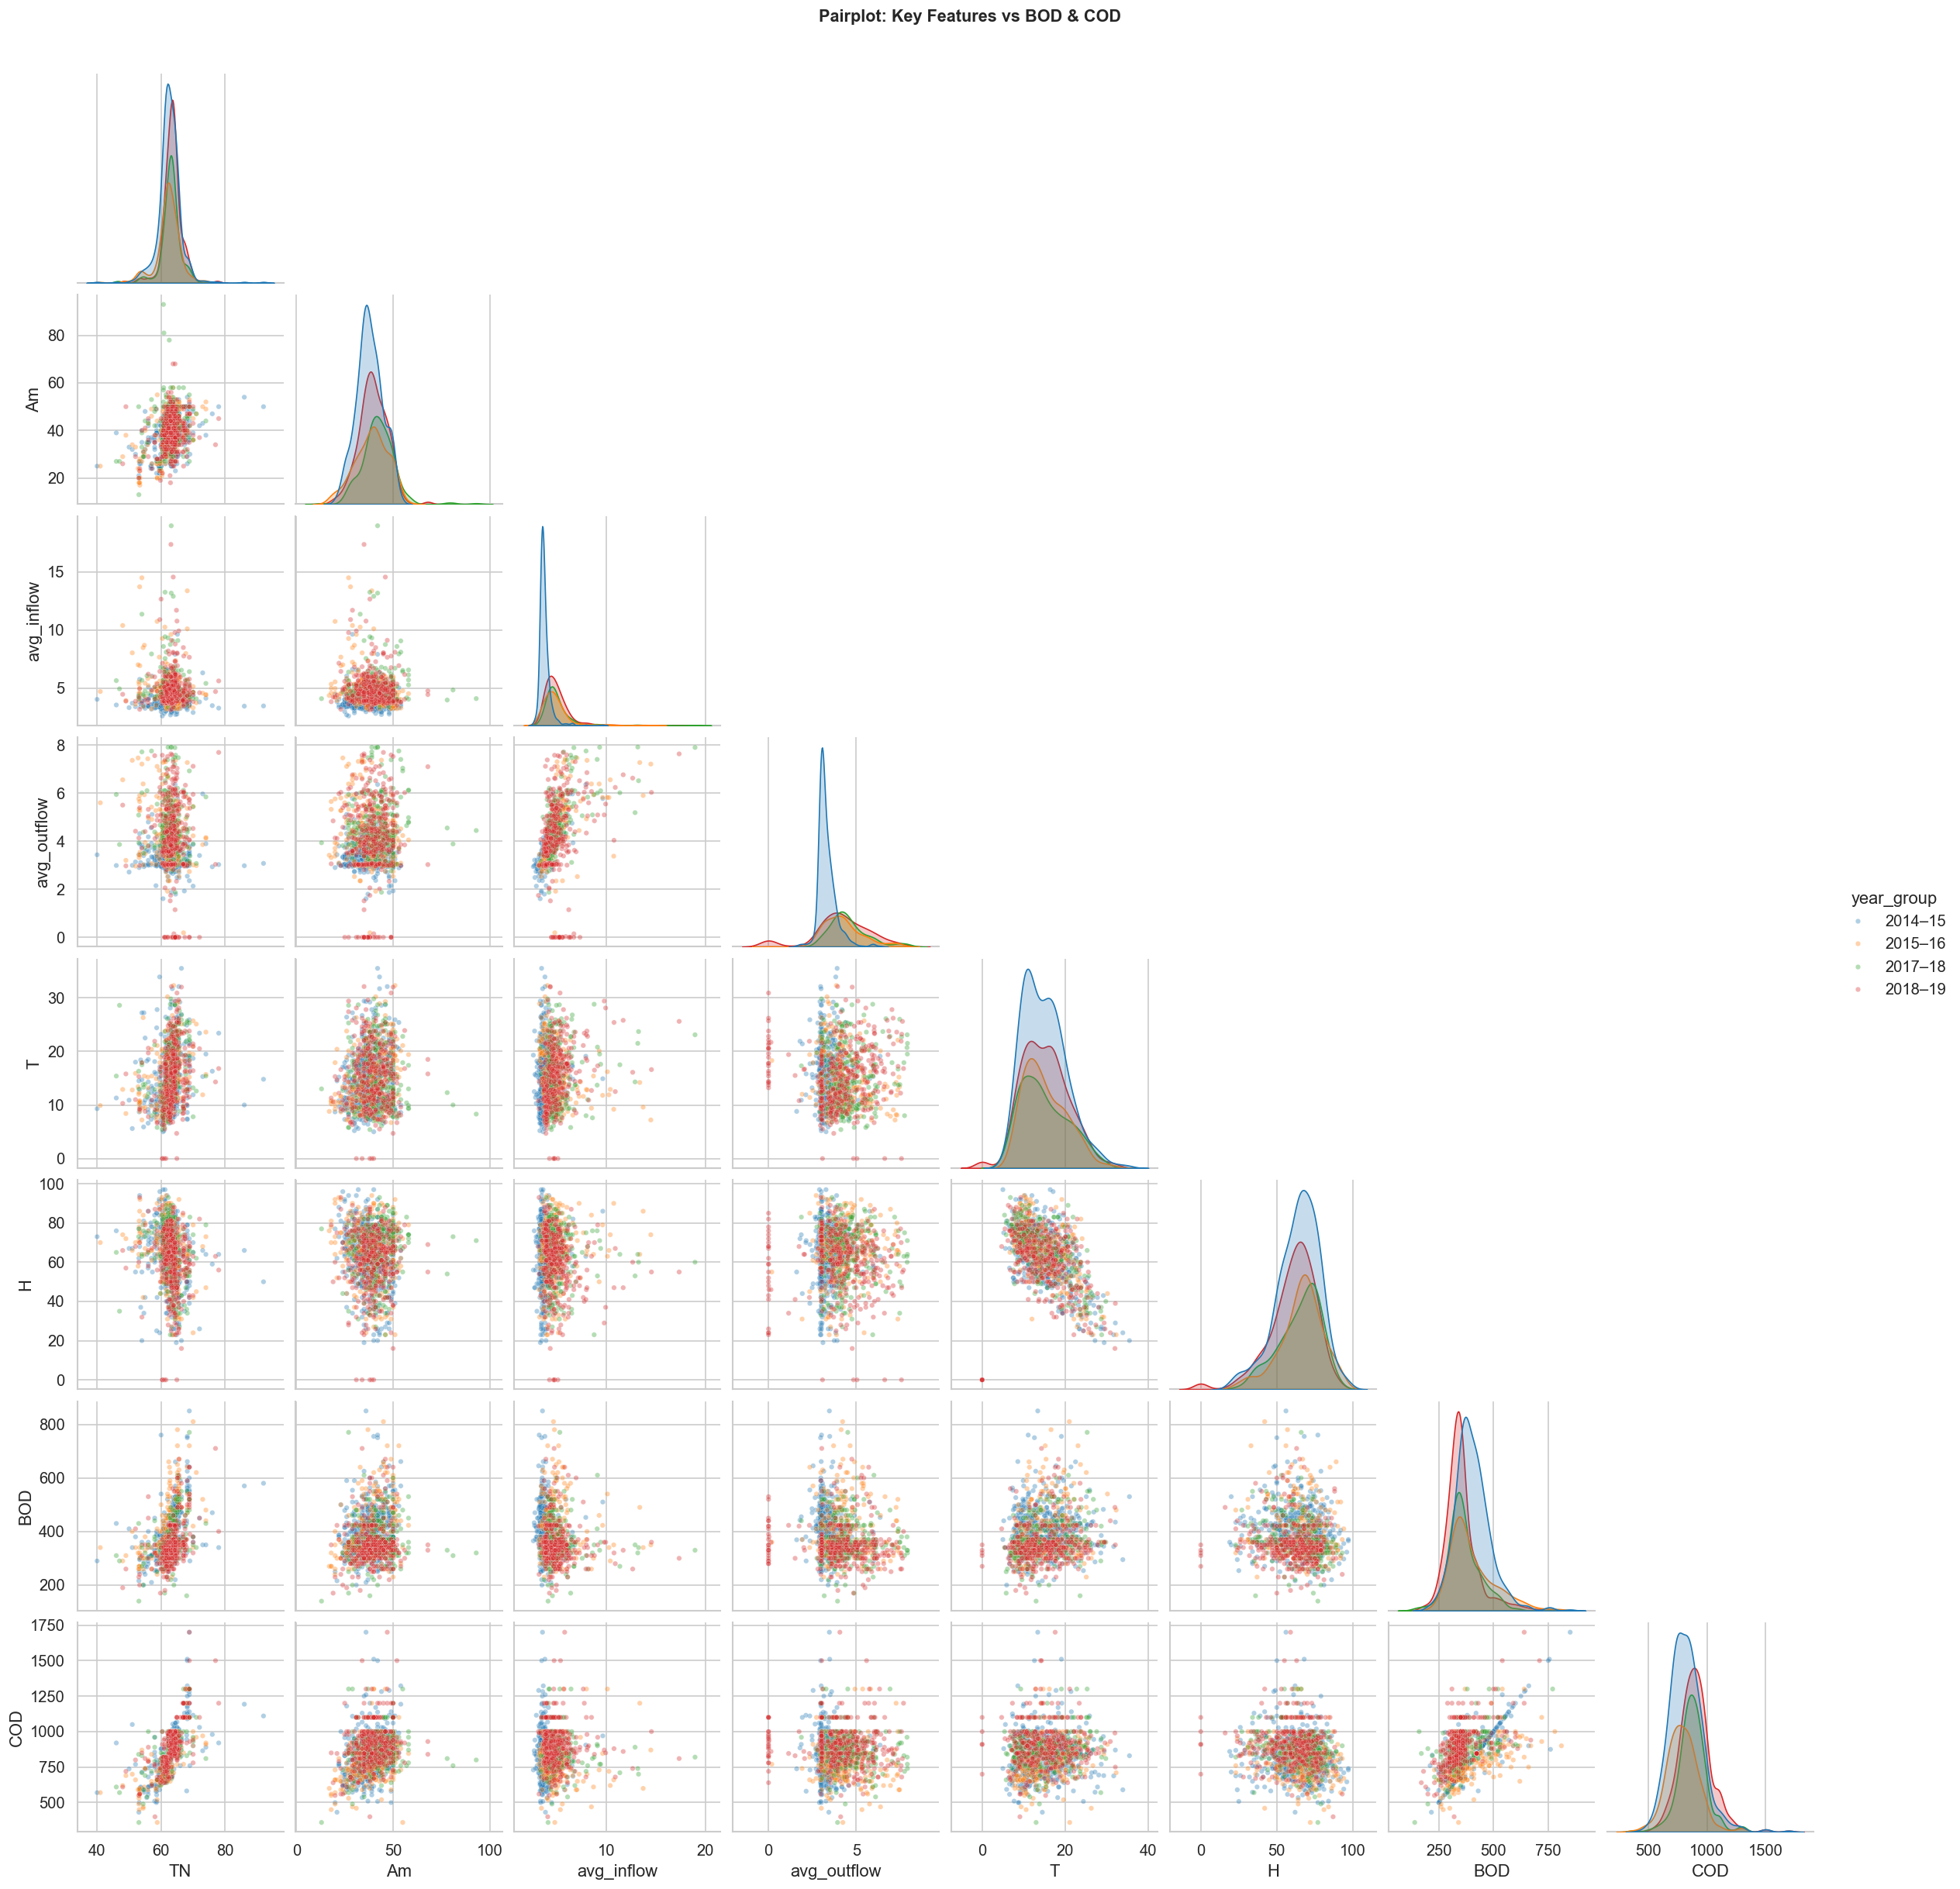

In [19]:
# Pairplot of key features vs BOD & COD 
# Useing only top correlated features to keep it readable
key_features = ['TN', 'Am', 'avg_inflow', 'avg_outflow', 'T', 'H', 'BOD', 'COD']

# Bin year into 4 groups for colour coding
df['year_group'] = pd.cut(df['year'], bins=4,
                          labels=['2014–15', '2015–16', '2017–18', '2018–19'])

pg = sns.pairplot(
    df[key_features + ['year_group']].dropna(),
    hue='year_group',
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 15},
    corner=True,
    palette='tab10'
)
pg.fig.suptitle('Pairplot: Key Features vs BOD & COD', y=1.02,
                fontsize=13, fontweight='bold')
pg.fig.savefig('fig_06_pairplot.png', bbox_inches='tight', dpi=100)
plt.show()

In [20]:
#  Multicollinearity check — correlation among features only 
feature_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in ['BOD', 'COD', 'year', 'month', 'day']]
feat_corr = df[feature_cols].corr().abs()

# Pairs with |r| > 0.75 (strong multicollinearity)
print("\n--- Feature Pairs with |Pearson r| > 0.75 (Multicollinearity Alert) ---")
reported = set()
for i in range(len(feat_corr.columns)):
    for j in range(i + 1, len(feat_corr.columns)):
        r = feat_corr.iloc[i, j]
        if r > 0.75:
            pair = (feat_corr.columns[i], feat_corr.columns[j])
            if pair not in reported:
                print(f"  {pair[0]:5s} <-> {pair[1]:5s} : r = {r:.3f}")
                reported.add(pair)


--- Feature Pairs with |Pearson r| > 0.75 (Multicollinearity Alert) ---
  T     <-> TM    : r = 0.925
  T     <-> Tm    : r = 0.891
  TM    <-> Tm    : r = 0.759
  V     <-> VM    : r = 0.824
  VM    <-> VG    : r = 0.809


## PREPROCESSING & FEATURE ENGINEERING

In [21]:
df.reset_index(drop=True, inplace=True)

In [22]:
df.shape

(1382, 22)

In [23]:
# Dropping redundant & noisy features based on correlation
# Rationale for each drop:
#   SLP  → near-zero correlation with both targets AND majority of values = 0
#   TM   → r=0.925 with T  (so keeping T: mean temp is more physically interpretable)
#   Tm   → r=0.891 with T
#   V    → r=0.824 with VM
#   VG   → r=0.809 with VM (keeping VM: max wind speed, strongest single wind signal)
#   day  → correlation ≈ 0 with all features and targets; adds only noise

DROP_COLS = ['SLP', 'TM', 'Tm', 'V', 'VG', 'day']
df.drop(columns=DROP_COLS, inplace=True)
print(f" Dropped columns: {DROP_COLS}")
print(f" Remaining columns: {df.columns.tolist()}")

 Dropped columns: ['SLP', 'TM', 'Tm', 'V', 'VG', 'day']
 Remaining columns: ['avg_outflow', 'avg_inflow', 'total_grid', 'Am', 'BOD', 'COD', 'TN', 'T', 'H', 'PP', 'VV', 'VM', 'year', 'month', 'date', 'year_group']


In [24]:
# In import and load data section, output showed min avg_outflow = 0.000004, not a true zero.
# The pandas .describe() rounded to 3 decimal places gave a misleading display.
# All avg_outflow values are physically valid. No imputation needed.
print(f"avg_outflow min value: {df['avg_outflow'].min():.8f}  → No zeros, no imputation needed.")

avg_outflow min value: 0.00000435  → No zeros, no imputation needed.


In [25]:
# Feature Engineering 
# We create domain-informed features that the literature supports:

# (a) BOD:COD ratio : indicates biodegradability of influent;
#     high ratio = more biodegradable load → impacts treatment efficiency
#     BOD and COD are our TARGET variables — any ratio or transform
#     of them (e.g., BOD/COD) used as an input feature would be
#     direct data leakage. We engineer features from other columns only.
#     BOD_lag1 and COD_lag1 (added below) are safe because they use
#     the PREVIOUS day's value, not the current day's target.

# (b) flow_ratio — DROPPED
# Attempted inflow/outflow ratio but avg_outflow contains near-zero values
# that create extreme ratios (max > 1M) even after 99th percentile clipping.
# avg_inflow and avg_outflow are retained as separate features, allowing
# tree-based models to learn their interaction directly without distortion.
print("[INFO] flow_ratio dropped — avg_inflow & avg_outflow retained separately.")

# (c) Thermal load index: T × H (temperature × humidity interaction) : Hot & humid days stress biological treatment processes  
df['temp_humidity'] = df['T'] * df['H']

# (d) Cyclic encoding of month (preserves Dec→Jan continuity)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# (e) Lag features for targets — previous day's BOD/COD is a strong (previous day — time-ordered split makes these leak-free)
df['BOD_lag1'] = df['BOD'].shift(1)
df['COD_lag1'] = df['COD'].shift(1)

# 7-day rolling mean of inflow (captures weekly operational patterns)
df['inflow_rolling7'] = df['avg_inflow'].rolling(window=7, min_periods=1).mean()

df.dropna(subset=['BOD_lag1', 'COD_lag1'], inplace=True)
df.reset_index(drop=True, inplace=True)

[INFO] flow_ratio dropped — avg_inflow & avg_outflow retained separately.


In [26]:
print(f"\n[INFO] Shape after feature engineering: {df.shape}")
print(f"[INFO] New features added: temp_humidity, "
      f"month_sin, month_cos, BOD_lag1, COD_lag1, inflow_rolling7")


[INFO] Shape after feature engineering: (1381, 22)
[INFO] New features added: temp_humidity, month_sin, month_cos, BOD_lag1, COD_lag1, inflow_rolling7


In [27]:
# FETURE SELECTION
TARGETS = ['BOD', 'COD']

# All engineered + retained features (exclude targets, date, raw month/year)
FEATURE_COLS = [
    'avg_outflow', 'avg_inflow', 'total_grid', 'Am', 'TN',
    'T', 'H', 'PP', 'VV', 'VM',
    'year', 'month_sin', 'month_cos',
    'temp_humidity', 'inflow_rolling7',
    'BOD_lag1', 'COD_lag1',
]

In [28]:
print(f"\n Final feature count: {len(FEATURE_COLS)}")
print(f" Features: {FEATURE_COLS}")


 Final feature count: 17
 Features: ['avg_outflow', 'avg_inflow', 'total_grid', 'Am', 'TN', 'T', 'H', 'PP', 'VV', 'VM', 'year', 'month_sin', 'month_cos', 'temp_humidity', 'inflow_rolling7', 'BOD_lag1', 'COD_lag1']


In [29]:
# Time-ordered Train / Validation / Test Split (70 / 10 / 20) 
n = len(df)
train_end  = int(n * 0.70)
val_end    = int(n * 0.80)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

In [30]:
print(f"\n--- Time-ordered Split ---")
print(f"  Train : {len(df_train):4d} rows  "
      f"({df_train['date'].min().date()} → {df_train['date'].max().date()})")
print(f"  Val   : {len(df_val):4d} rows  "
      f"({df_val['date'].min().date()} → {df_val['date'].max().date()})")
print(f"  Test  : {len(df_test):4d} rows  "
      f"({df_test['date'].min().date()} → {df_test['date'].max().date()})")


--- Time-ordered Split ---
  Train :  966 rows  (2014-01-02 → 2017-10-19)
  Val   :  138 rows  (2017-10-22 → 2018-05-07)
  Test  :  277 rows  (2018-05-08 → 2019-06-27)


In [31]:
# Scaling
# StandardScaler: fit ONLY on training data to prevent data leakage
# Applied to both features AND targets for LSTM later.
# Tree models don't need scaling but we keep a scaled copy for consistency.

scaler_X = StandardScaler()
scaler_y_BOD = StandardScaler()
scaler_y_COD = StandardScaler()

# Fit on train, transform all splits
X_train = scaler_X.fit_transform(df_train[FEATURE_COLS])
X_val   = scaler_X.transform(df_val[FEATURE_COLS])
X_test  = scaler_X.transform(df_test[FEATURE_COLS])

# Target scaling (used for LSTM; tree models use raw targets)
y_train_BOD = df_train['BOD'].values
y_val_BOD   = df_val['BOD'].values
y_test_BOD  = df_test['BOD'].values

y_train_COD = df_train['COD'].values
y_val_COD   = df_val['COD'].values
y_test_COD  = df_test['COD'].values

# Converting back to DataFrames with feature names (needed for SHAP later)
X_train_df = pd.DataFrame(X_train, columns=FEATURE_COLS)
X_val_df   = pd.DataFrame(X_val,   columns=FEATURE_COLS)
X_test_df  = pd.DataFrame(X_test,  columns=FEATURE_COLS)

In [32]:
print(f"  X_train shape : {X_train_df.shape}")
print(f"  X_val shape   : {X_val_df.shape}")
print(f"  X_test shape  : {X_test_df.shape}")

  X_train shape : (966, 17)
  X_val shape   : (138, 17)
  X_test shape  : (277, 17)


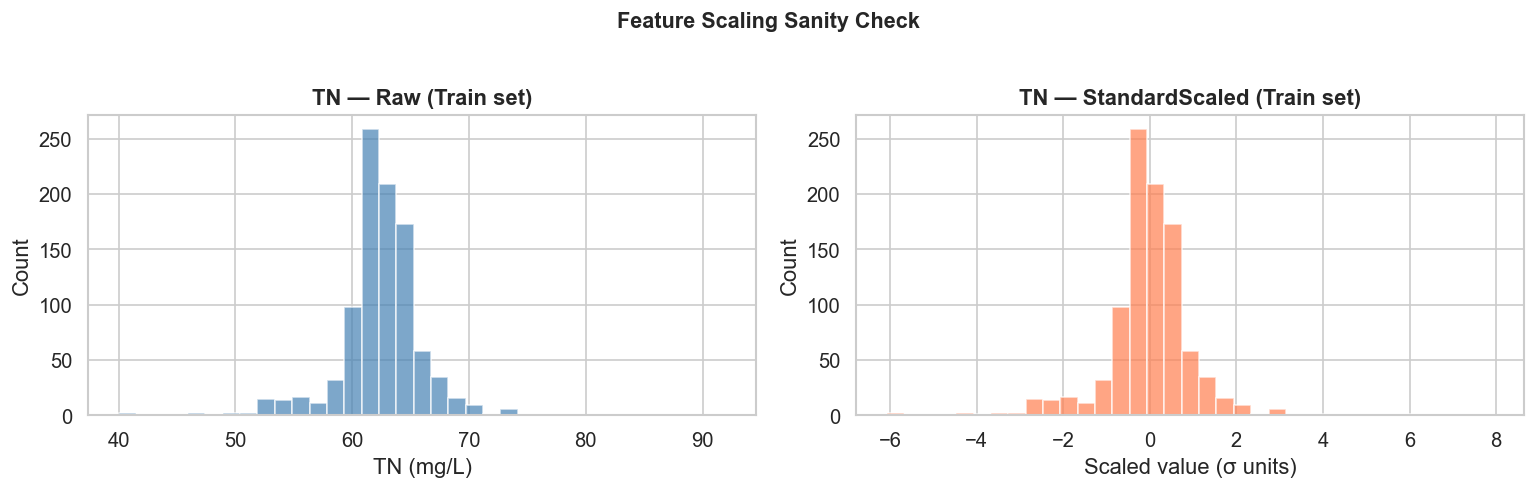

In [33]:
# Quick sanity-check plot: feature distributions before/after scaling
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before scaling — raw TN (strongest predictor)
axes[0].hist(df_train['TN'], bins=35, color='steelblue',
             alpha=0.7, edgecolor='white')
axes[0].set_title('TN — Raw (Train set)', fontweight='bold')
axes[0].set_xlabel('TN (mg/L)')
axes[0].set_ylabel('Count')

# After scaling
axes[1].hist(X_train_df['TN'], bins=35, color='coral',
             alpha=0.7, edgecolor='white')
axes[1].set_title('TN — StandardScaled (Train set)', fontweight='bold')
axes[1].set_xlabel('Scaled value (σ units)')
axes[1].set_ylabel('Count')

plt.suptitle('Feature Scaling Sanity Check', fontsize=13,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_07_scaling_check.png', bbox_inches='tight')
plt.show()

In [34]:
# Saving processed splits for use in subsequent steps

# Saving unscaled dataframes (trees need raw; scalers saved separately)
df_train.to_csv('split_train.csv', index=False)
df_val.to_csv('split_val.csv',     index=False)
df_test.to_csv('split_test.csv',   index=False)

# Saving scaler for deployment (Streamlit app will need it)
import joblib
joblib.dump(scaler_X,     'scaler_X.pkl')
joblib.dump(scaler_y_BOD, 'scaler_y_BOD.pkl')
joblib.dump(scaler_y_COD, 'scaler_y_COD.pkl')

print("\n[SAVED] split_train.csv, split_val.csv, split_test.csv")
print("[SAVED] scaler_X.pkl, scaler_y_BOD.pkl, scaler_y_COD.pkl")


[SAVED] split_train.csv, split_val.csv, split_test.csv
[SAVED] scaler_X.pkl, scaler_y_BOD.pkl, scaler_y_COD.pkl


## RANDOM FOREST: BASELINE TRAINING & EVALUATION

In [35]:
# Helper: evaluation metrics 
def evaluate(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  [{label}]  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [36]:
# Helper: actual vs predicted plot
def plot_actual_vs_pred(y_true, y_pred, target, split_label, filename):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Scatter: actual vs predicted
    axes[0].scatter(y_true, y_pred, alpha=0.4, s=18, color='steelblue'
                    if target == 'BOD' else 'coral')
    lims = [min(y_true.min(), y_pred.min()) - 10,
            max(y_true.max(), y_pred.max()) + 10]
    axes[0].plot(lims, lims, 'k--', linewidth=1.5, label='Perfect fit')
    axes[0].set_xlabel(f'Actual {target} (mg/L)')
    axes[0].set_ylabel(f'Predicted {target} (mg/L)')
    axes[0].set_title(f'{target} — Actual vs Predicted ({split_label})',
                      fontweight='bold')
    axes[0].legend()

    # Residuals
    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.4, s=18,
                    color='steelblue' if target == 'BOD' else 'coral')
    axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel(f'Predicted {target} (mg/L)')
    axes[1].set_ylabel('Residual (Actual − Predicted)')
    axes[1].set_title(f'{target} — Residuals ({split_label})', fontweight='bold')

    plt.suptitle(f'Random Forest — {target} ({split_label})',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {filename}")

In [37]:
# Combining train + val for final RF fit 
# We train the BASELINE on train only first, then report val & test metrics.
# Tree models do not use val for early stopping — val is used only for Optuna tuning. Here we use default hyperparameters.

X_trainval = np.vstack([X_train, X_val])
y_trainval_COD = np.concatenate([y_train_COD, y_val_COD])

# n_estimators=200: enough trees for stable predictions without excess cost
# random_state=42: reproducibility
# n_jobs=-1: use all CPU cores
# Training RandomForest — COD
print("  RANDOM FOREST — COD")

rf_cod = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_cod.fit(X_train, y_train_COD)

pred_val_cod  = rf_cod.predict(X_val)
pred_test_cod = rf_cod.predict(X_test)

  RANDOM FOREST — COD


In [38]:
print("\n  --- COD Performance ---")
metrics_rf_cod_val  = evaluate(y_val_COD,  pred_val_cod,  label="Val ")
metrics_rf_cod_test = evaluate(y_test_COD, pred_test_cod, label="Test")


  --- COD Performance ---
  [Val ]  MAE=59.385  RMSE=96.451  R²=0.6472
  [Test]  MAE=58.474  RMSE=75.813  R²=0.6675


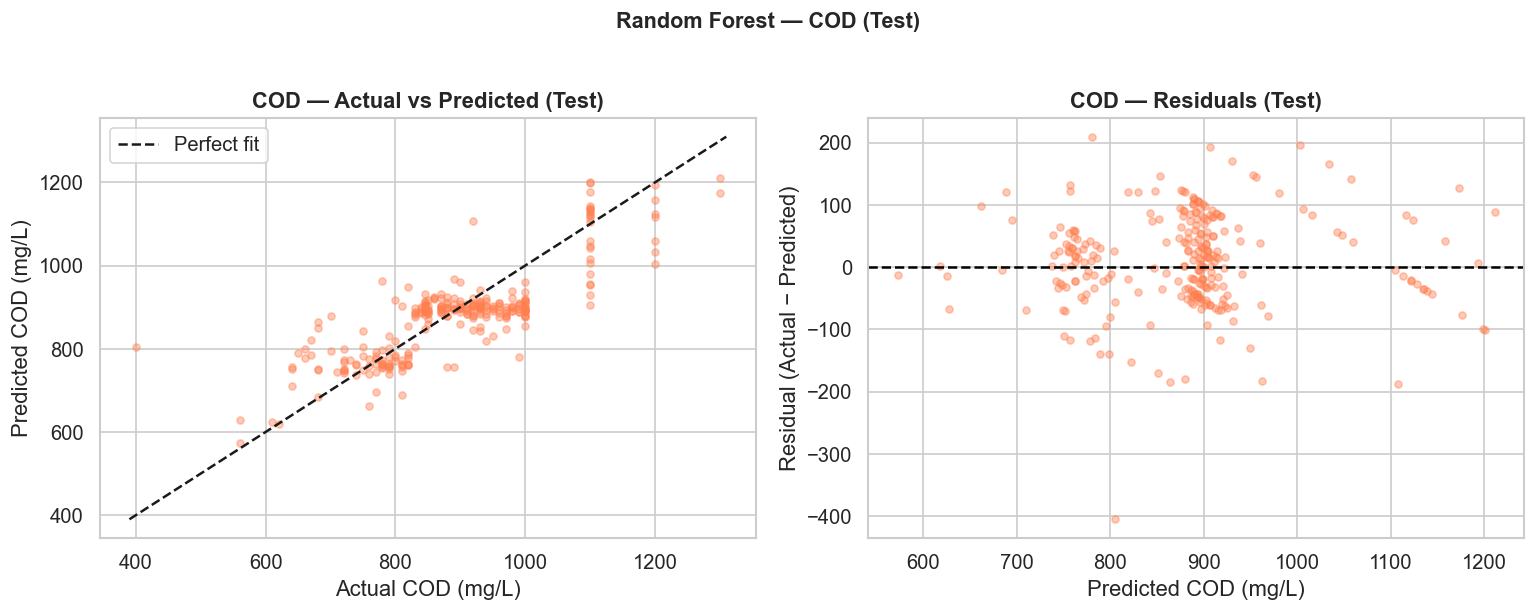

[SAVED] fig_09_rf_cod_test.png


In [39]:
# ── 4.4  Actual vs Predicted plots ────────────────────────────────────────────
plot_actual_vs_pred(y_test_COD, pred_test_cod,
                    'COD', 'Test', 'fig_09_rf_cod_test.png')

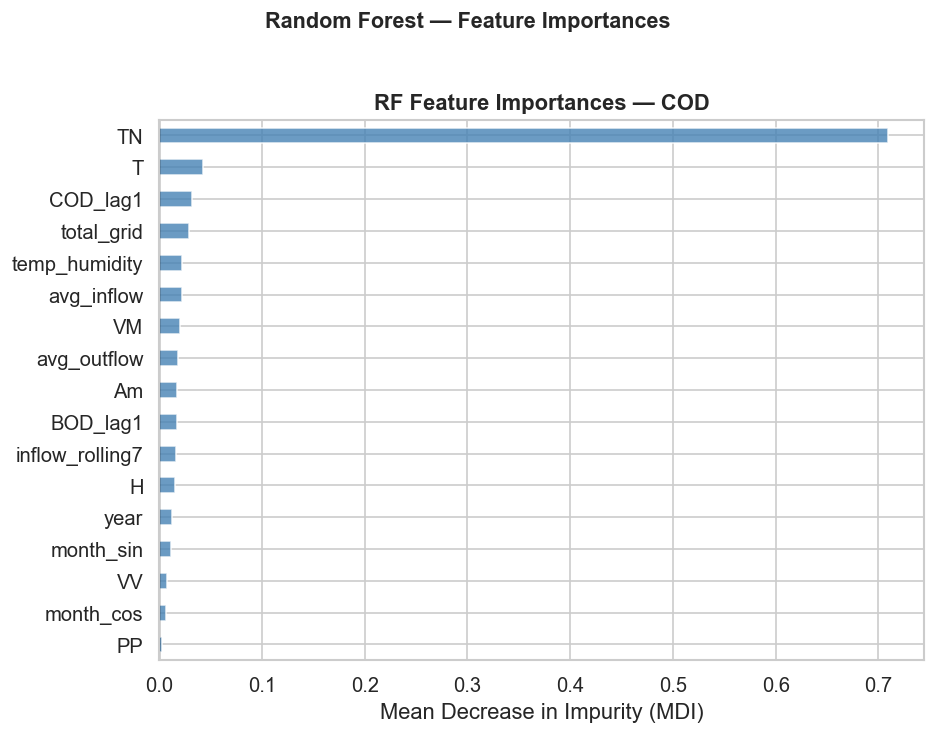

In [40]:
# Feature Importance plot
fig, ax = plt.subplots(figsize=(8, 6))

model = rf_cod
target = 'COD'
color = 'steelblue'

importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importances_sorted = importances.sort_values(ascending=True)

importances_sorted.plot.barh(
    ax=ax, color=color, alpha=0.8, edgecolor='white'
)

ax.set_title(f'RF Feature Importances — {target}', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity (MDI)')
ax.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Random Forest — Feature Importances',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fig_10_rf_feature_importance.png', bbox_inches='tight')
plt.show()

In [41]:
#  Summary table
print("\n--- RF Baseline Summary (Test Set) ---")
print(f"  COD → MAE: {metrics_rf_cod_test['MAE']:.2f} mg/L | "
      f"RMSE: {metrics_rf_cod_test['RMSE']:.2f} mg/L | "
      f"R²: {metrics_rf_cod_test['R2']:.4f}")


--- RF Baseline Summary (Test Set) ---
  COD → MAE: 58.47 mg/L | RMSE: 75.81 mg/L | R²: 0.6675


#### DIAGNOSTIC — Understanding the BOD test failure

### FINDING — BOD DISTRIBUTION SHIFT

The test set (May 2018 – Jun 2019) exhibits a structural shift in BOD: mean dropped from 393 to 338 mg/L and std compressed from 88 to 58 mg/L.
This reflects a real operational change at the plant (likely infrastructure upgrade or load reduction), not a modelling error.

Consequence: All models will show reduced BOD R² on test. This is expected and will be reported transparently in the Results & Discussion section. COD is unaffected — test mean (887) within train range.

## XGBOOST : TRAINING & EVALUATION

In [42]:
print(f"[INFO] XGBoost version: {xgb.__version__}")

# Training XGBoost — BOD

# early_stopping_rounds: stops training if val score doesn't improve for 50 consecutive rounds — prevents overfitting
# eval_metric='rmse': monitors RMSE on validation set , verbose=False: suppresses per-round output

# Training XGBoost — COD 
print("  XGBOOST — COD")

xgb_cod = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='rmse',
    verbosity=0
)

xgb_cod.fit(
    X_train, y_train_COD,
    eval_set=[(X_val, y_val_COD)],
    verbose=False
)

best_round_cod = xgb_cod.best_iteration
print(f"  Best iteration (early stopping): {best_round_cod}")

pred_val_cod_xgb  = xgb_cod.predict(X_val)
pred_test_cod_xgb = xgb_cod.predict(X_test)

[INFO] XGBoost version: 3.2.0
  XGBOOST — COD
  Best iteration (early stopping): 143


In [43]:
print("\n  --- COD Performance ---")
metrics_xgb_cod_val  = evaluate(y_val_COD,  pred_val_cod_xgb,  label="Val ")
metrics_xgb_cod_test = evaluate(y_test_COD, pred_test_cod_xgb, label="Test")


  --- COD Performance ---
  [Val ]  MAE=58.046  RMSE=95.507  R²=0.6541
  [Test]  MAE=58.025  RMSE=76.318  R²=0.6630


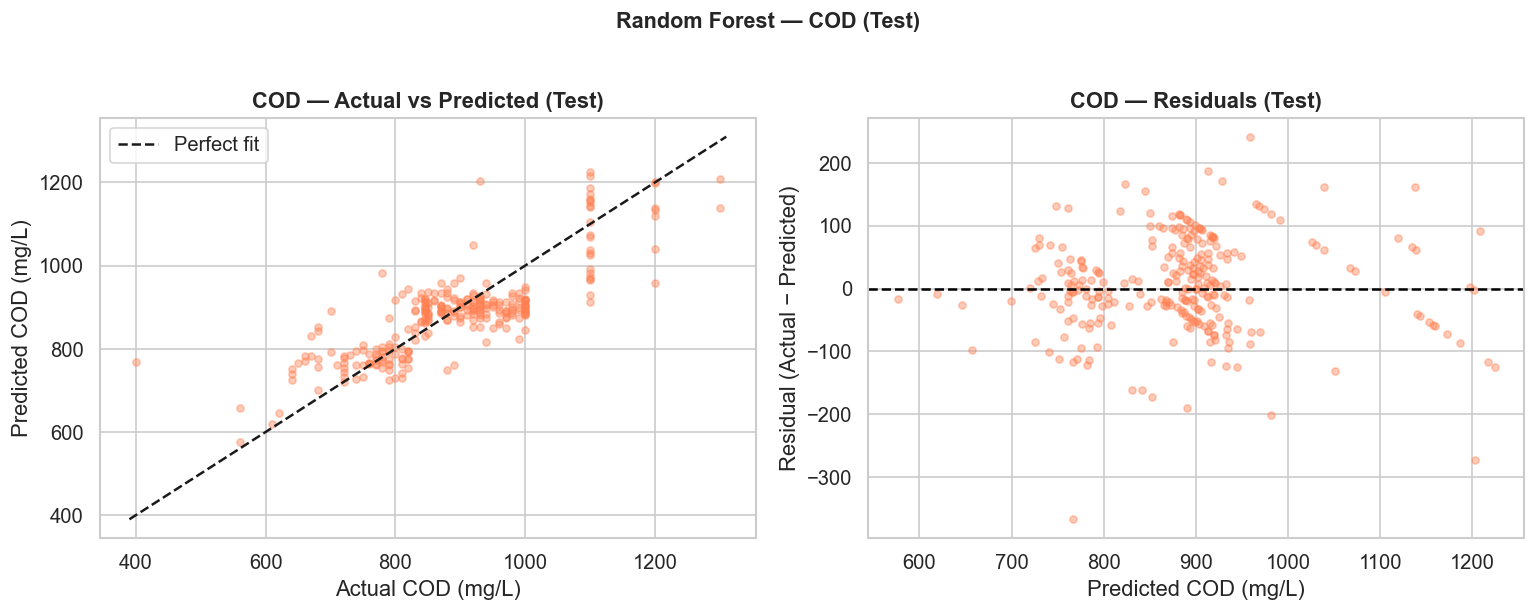

[SAVED] fig_12_xgb_cod_test.png


In [44]:
# ── 5.3  Actual vs Predicted plots ────────────────────────────────────────────
plot_actual_vs_pred(y_test_COD, pred_test_cod_xgb,
                    'COD', 'Test', 'fig_12_xgb_cod_test.png')

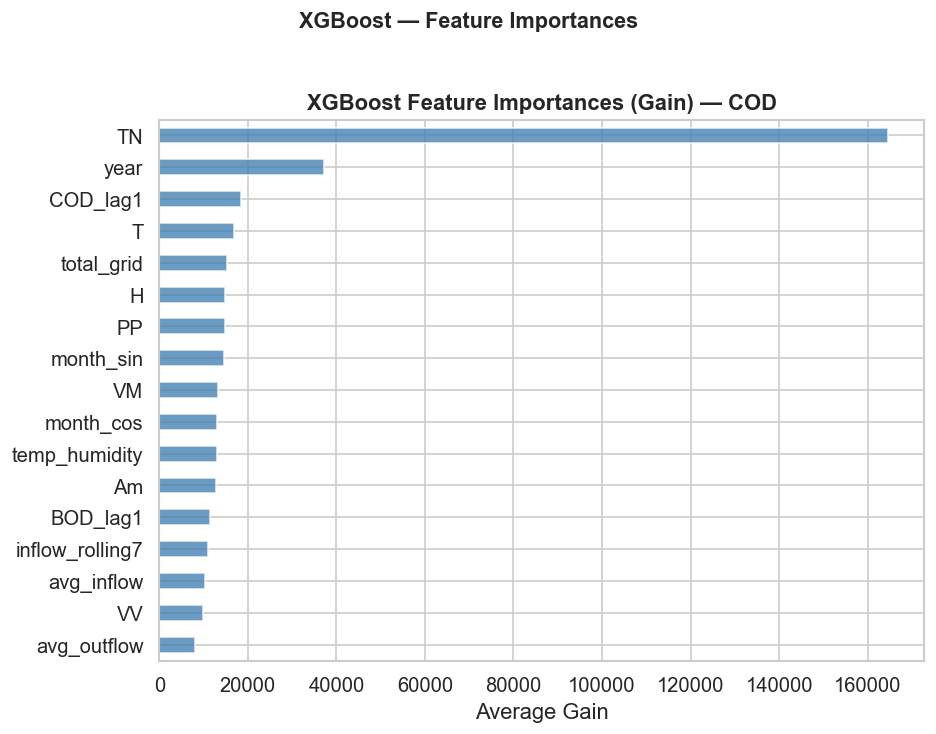

In [45]:
# Feature Importance
fig, ax = plt.subplots(figsize=(8, 6))

model = xgb_cod
target = 'COD'
color = 'steelblue'

# 'gain' importance
score_dict = model.get_booster().get_score(importance_type='gain')

importances = pd.Series(score_dict)

# Map f0, f1... to actual feature names
feat_map = {f'f{i}': name for i, name in enumerate(FEATURE_COLS)}
importances.index = [feat_map.get(i, i) for i in importances.index]

importances_sorted = importances.sort_values(ascending=True)

importances_sorted.plot.barh(
    ax=ax, color=color, alpha=0.8, edgecolor='white'
)

ax.set_title(f'XGBoost Feature Importances (Gain) — {target}',
             fontweight='bold')
ax.set_xlabel('Average Gain')

plt.suptitle('XGBoost — Feature Importances',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fig_13_xgb_feature_importance.png', bbox_inches='tight')
plt.show()

In [46]:
#RF vs XGBoost comparison table
print("  MODEL COMPARISON — TEST SET")
print("=" * 65)
print(f"  {'Model':<20} {'Target':<6} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 65)
print(f"  {'Random Forest':<20} {'COD':<6} "
      f"{metrics_rf_cod_test['MAE']:>8.2f} "
      f"{metrics_rf_cod_test['RMSE']:>8.2f} "
      f"{metrics_rf_cod_test['R2']:>8.4f}")
print(f"  {'XGBoost':<20} {'COD':<6} "
      f"{metrics_xgb_cod_test['MAE']:>8.2f} "
      f"{metrics_xgb_cod_test['RMSE']:>8.2f} "
      f"{metrics_xgb_cod_test['R2']:>8.4f}")
print("=" * 65)

  MODEL COMPARISON — TEST SET
  Model                Target      MAE     RMSE       R²
-----------------------------------------------------------------
  Random Forest        COD       58.47    75.81   0.6675
  XGBoost              COD       58.03    76.32   0.6630


In [47]:
# ── 5.6  Save XGBoost models ──────────────────────────────────────────────────
import joblib
joblib.dump(xgb_cod, 'xgb_cod.pkl')
print("\n[SAVED] xgb_bod.pkl, xgb_cod.pkl")


[SAVED] xgb_bod.pkl, xgb_cod.pkl


## SHAP ANALYSIS — XGBoost COD Model

In [48]:
# Creating SHAP explainer 
explainer_cod = shap.TreeExplainer(xgb_cod)

print("[INFO] Computing SHAP values for COD...")
shap_values_cod = explainer_cod(X_test_df)

print(f"[INFO] SHAP computation complete.")
print(f"  SHAP values shape: {shap_values_cod.values.shape}")

[INFO] Computing SHAP values for COD...
[INFO] SHAP computation complete.
  SHAP values shape: (277, 17)


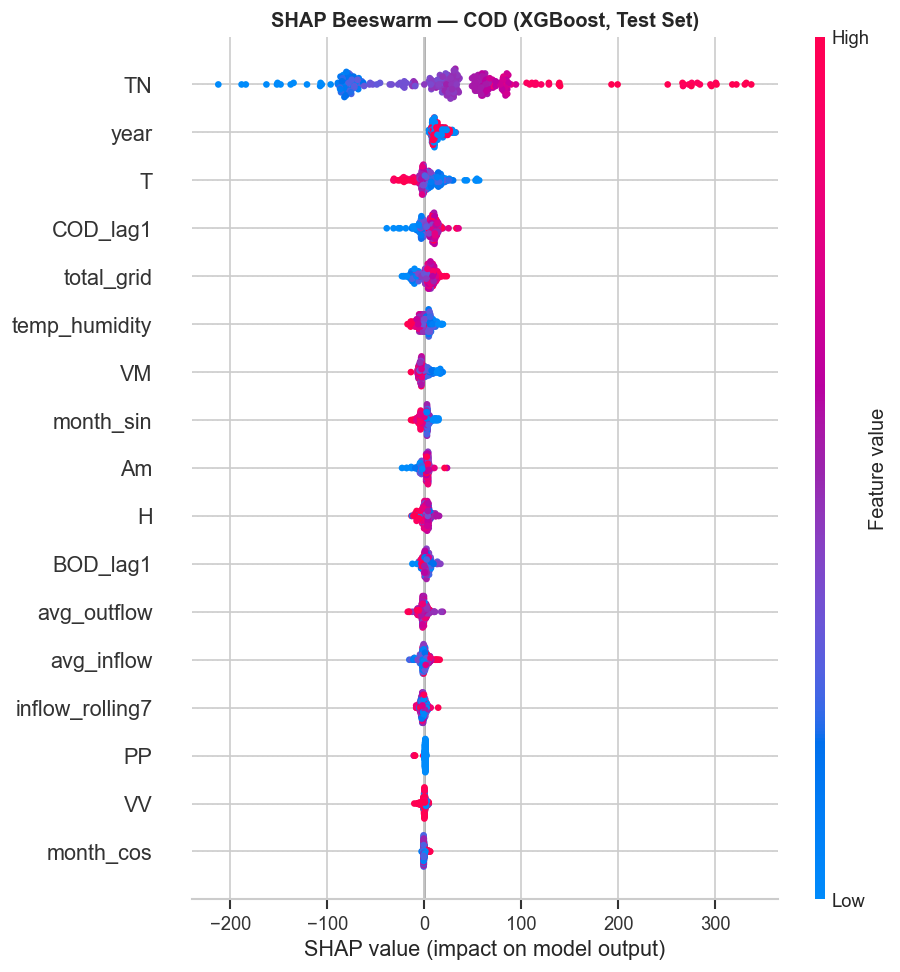

[SAVED] fig_14_shap_beeswarm_cod.png


In [49]:
# Beeswarm plot 
# Most informative SHAP plot:
# x-axis  : SHAP value (positive = pushes prediction higher)
# colour  : feature value (red=high, blue=low)

fig, ax = plt.subplots(figsize=(10, 7))
plt.sca(ax)
shap.plots.beeswarm(shap_values_cod, max_display=17, show=False)
ax.set_title('SHAP Beeswarm — COD (XGBoost, Test Set)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig_14_shap_beeswarm_cod.png', bbox_inches='tight', dpi=120)
plt.show()
print("[SAVED] fig_14_shap_beeswarm_cod.png")

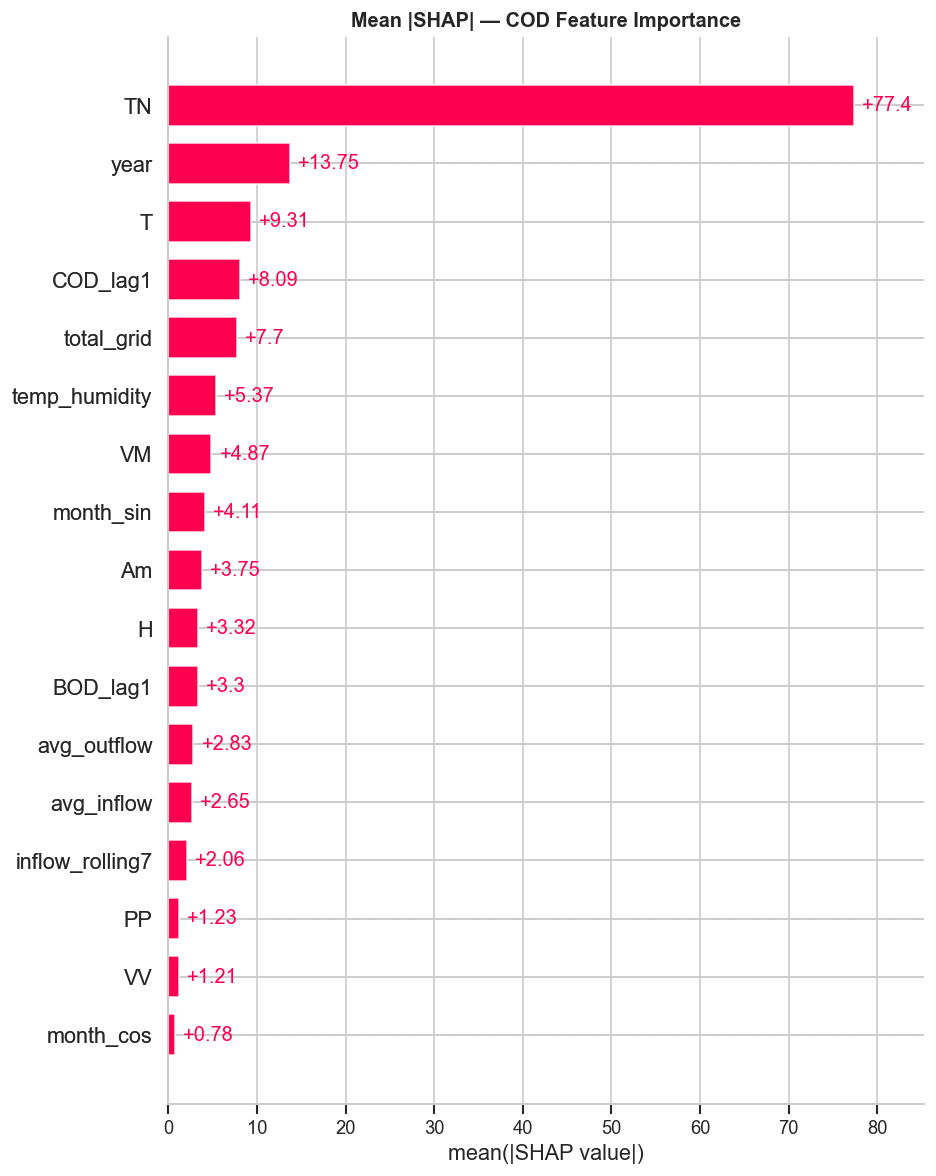

[SAVED] fig_15_shap_bar_cod.png


In [50]:
# Bar plot (mean absolute SHAP) 
# Clean global feature importance ranking
fig, ax = plt.subplots(figsize=(9, 6))
plt.sca(ax)
shap.plots.bar(shap_values_cod, max_display=17, show=False)
ax.set_title('Mean |SHAP| — COD Feature Importance',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig_15_shap_bar_cod.png', bbox_inches='tight', dpi=120)
plt.show()
print("[SAVED] fig_15_shap_bar_cod.png")

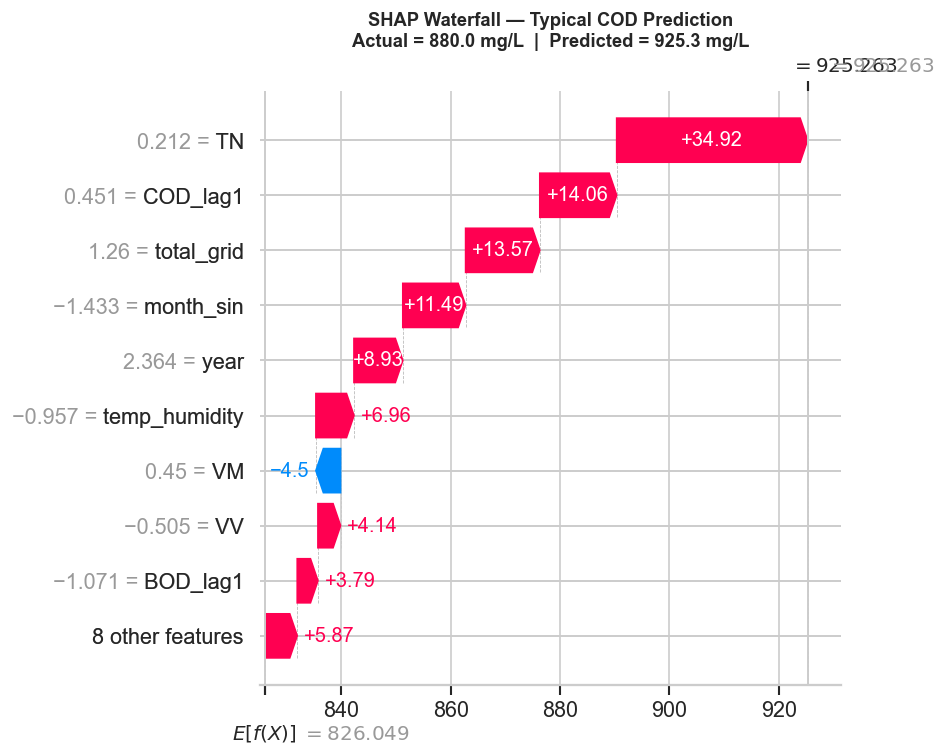

[SAVED] fig_16_shap_waterfall_cod.png


In [51]:
#  Waterfall plot — single prediction explanation
# Pick the test sample closest to median COD
median_idx = np.argmin(np.abs(y_test_COD - np.median(y_test_COD)))

fig, ax = plt.subplots(figsize=(10, 6))
plt.sca(ax)
shap.plots.waterfall(shap_values_cod[median_idx], show=False)
ax.set_title(
    f'SHAP Waterfall — Typical COD Prediction\n'
    f'Actual = {y_test_COD[median_idx]:.1f} mg/L  |  '
    f'Predicted = {pred_test_cod_xgb[median_idx]:.1f} mg/L',
    fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('fig_16_shap_waterfall_cod.png', bbox_inches='tight', dpi=120)
plt.show()
print("[SAVED] fig_16_shap_waterfall_cod.png")

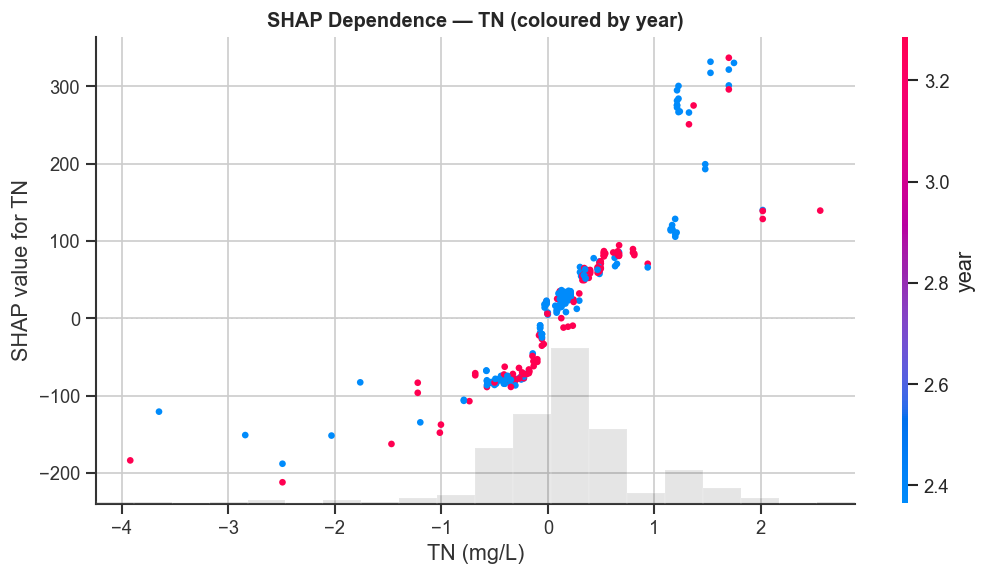

[SAVED] fig_17_shap_dependence_TN.png


In [52]:
# SHAP Dependence plot — TN (strongest feature) 
# Shows how TN's SHAP value changes across its range
fig, ax = plt.subplots(figsize=(9, 5))
shap.plots.scatter(shap_values_cod[:, 'TN'],
                   color=shap_values_cod[:, 'year'],
                   ax=ax, show=False)
ax.set_title('SHAP Dependence — TN (coloured by year)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('TN (mg/L)')
ax.set_ylabel('SHAP value for TN')
plt.tight_layout()
plt.savefig('fig_17_shap_dependence_TN.png', bbox_inches='tight', dpi=120)
plt.show()
print("[SAVED] fig_17_shap_dependence_TN.png")

In [53]:
# Print SHAP feature ranking
print("\n--- Mean |SHAP| Feature Ranking — COD (Test Set) ---")
shap_cod_mean = pd.Series(
    np.abs(shap_values_cod.values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False)
print(shap_cod_mean.round(3).to_string())


--- Mean |SHAP| Feature Ranking — COD (Test Set) ---
TN                 77.401001
year               13.751000
T                   9.306000
COD_lag1            8.092000
total_grid          7.701000
temp_humidity       5.370000
VM                  4.868000
month_sin           4.113000
Am                  3.749000
H                   3.316000
BOD_lag1            3.295000
avg_outflow         2.833000
avg_inflow          2.645000
inflow_rolling7     2.059000
PP                  1.227000
VV                  1.211000
month_cos           0.776000


In [54]:
# Group features into operational vs weather for report narrative
operational = ['avg_outflow', 'avg_inflow', 'total_grid',
               'Am', 'TN', 'inflow_rolling7',
               'BOD_lag1', 'COD_lag1']
weather      = ['T', 'H', 'PP', 'VV', 'VM',
                'temp_humidity', 'month_sin', 'month_cos', 'year']

op_importance  = shap_cod_mean[
    [f for f in operational if f in shap_cod_mean.index]].sum()
wx_importance  = shap_cod_mean[
    [f for f in weather if f in shap_cod_mean.index]].sum()
total          = op_importance + wx_importance

print(f"\n--- Feature Group Contribution ---")
print(f"  Operational features : {op_importance:.3f} "
      f"({100*op_importance/total:.1f}%)")
print(f"  Weather/temporal     : {wx_importance:.3f} "
      f"({100*wx_importance/total:.1f}%)")


--- Feature Group Contribution ---
  Operational features : 107.776 (71.0%)
  Weather/temporal     : 43.937 (29.0%)


## ISOLATION FOREST : ANOMALY DETECTION

In [55]:
# Prepare data

# Using unscaled dataframes — refitting a fresh scaler here for clarity (anomaly detection is a separate pipeline from COD prediction)
scaler_iso = StandardScaler()
X_train_iso = scaler_iso.fit_transform(df_train[FEATURE_COLS])
X_val_iso   = scaler_iso.transform(df_val[FEATURE_COLS])
X_test_iso  = scaler_iso.transform(df_test[FEATURE_COLS])

# Full dataset scaled (for full timeline plot)
X_all_iso   = scaler_iso.transform(df[FEATURE_COLS])

print(f"[INFO] Train shape for Isolation Forest: {X_train_iso.shape}")

[INFO] Train shape for Isolation Forest: (966, 17)


In [56]:
# Train Isolation Forest
# contamination=0.05: we expect ~5% of training days to be anomalous (consistent with our IQR outlier finding of 4.2% BOD, 3.2% COD)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_iso)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [57]:
# Score entire dataset
# decision_function returns anomaly score: more negative = more anomalous, positive = normal
# predict returns: -1 (anomaly) or +1 (normal)

df['iso_score']  = iso_forest.decision_function(X_all_iso)
df['iso_label']  = iso_forest.predict(X_all_iso)
# Convert to readable label
df['iso_anomaly'] = df['iso_label'].map({1: 'Normal', -1: 'Anomaly'})

# Summary counts
total_anomalies = (df['iso_label'] == -1).sum()
train_anom = (df_train.index.isin(
    df[df['iso_label']==-1].index)).sum()

print(f"\n[INFO] Total anomalies detected: {total_anomalies} "
      f"({100*total_anomalies/len(df):.1f}%)")

# Counting anomalies per split
for name, idx_start, idx_end in [
    ('Train', 0, len(df_train)),
    ('Val',   len(df_train), len(df_train)+len(df_val)),
    ('Test',  len(df_train)+len(df_val), len(df))]:
    subset = df.iloc[idx_start:idx_end]
    n_anom = (subset['iso_label'] == -1).sum()
    print(f"  {name:6s}: {n_anom:4d} anomalies "
          f"({100*n_anom/len(subset):.1f}%)")


[INFO] Total anomalies detected: 100 (7.2%)
  Train :   49 anomalies (5.1%)
  Val   :   23 anomalies (16.7%)
  Test  :   28 anomalies (10.1%)


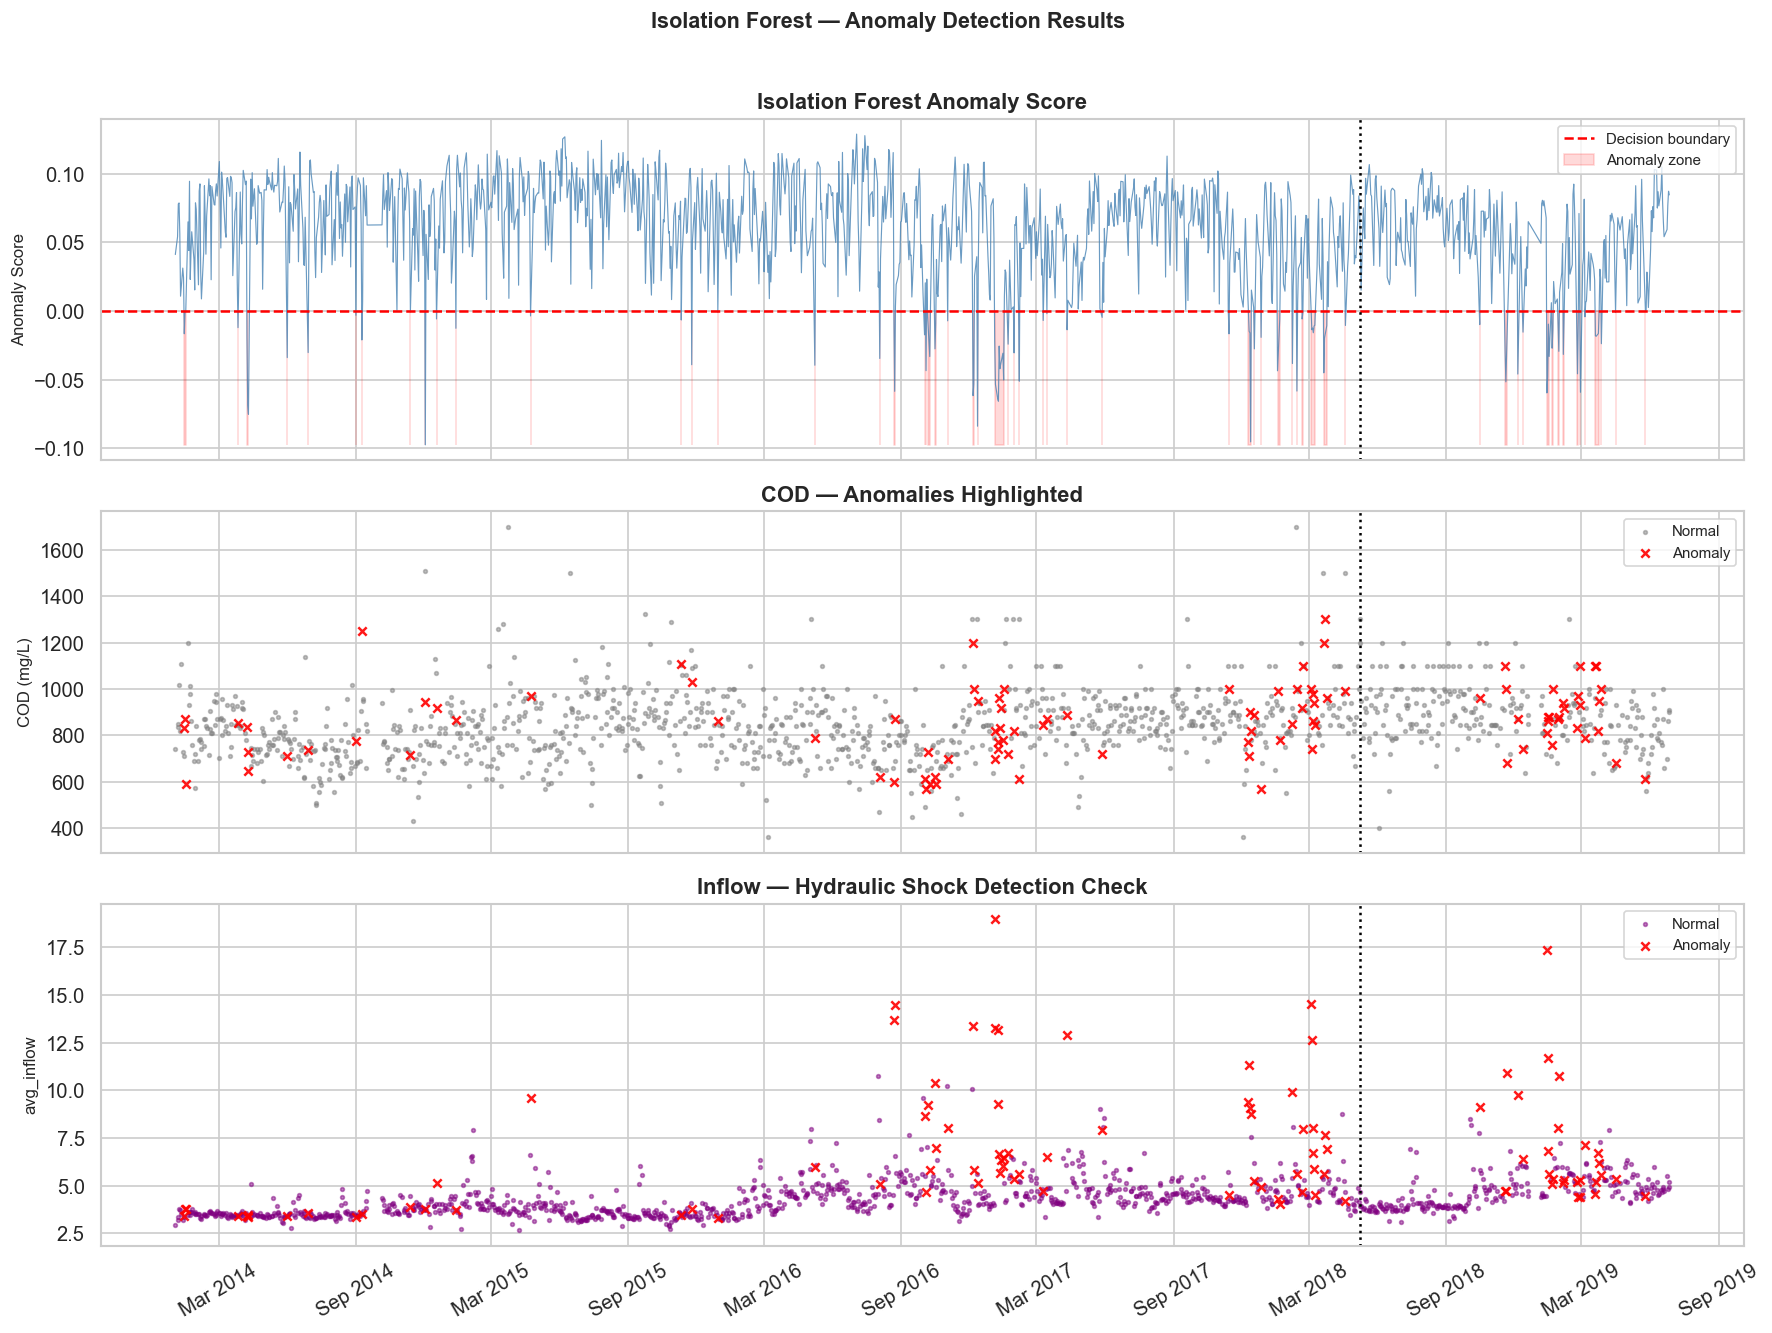

[SAVED] fig_18_isolation_forest.png


In [65]:
# Full timeline anomaly plot
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# Panel 1: Anomaly score over time
axes[0].plot(df['date'], df['iso_score'],
             color='steelblue', linewidth=0.7, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--',
                linewidth=1.5, label='Decision boundary')
# Shade anomaly regions
axes[0].fill_between(df['date'],
                     df['iso_score'].min(), 0,
                     where=(df['iso_score'] < 0),
                     alpha=0.15, color='red', label='Anomaly zone')
axes[0].set_ylabel('Anomaly Score', fontsize=10)
axes[0].set_title('Isolation Forest Anomaly Score', fontweight='bold')
axes[0].legend(fontsize=9)

# Panel 2: COD with anomalies highlighted
normal_mask  = df['iso_label'] == 1
anomaly_mask = df['iso_label'] == -1
axes[1].scatter(df.loc[normal_mask,  'date'],
                df.loc[normal_mask,  'COD'],
                s=5, alpha=0.5, color='gray',   label='Normal')
axes[1].scatter(df.loc[anomaly_mask, 'date'],
                df.loc[anomaly_mask, 'COD'],
                s=25, alpha=0.9, color='red',
                marker='x', label='Anomaly', zorder=5)
axes[1].set_ylabel('COD (mg/L)', fontsize=10)
axes[1].set_title('COD — Anomalies Highlighted', fontweight='bold')
axes[1].legend(fontsize=9)

# Panel 3: avg_inflow with anomalies (hydraulic shock detection check)
axes[2].scatter(df.loc[normal_mask,  'date'],
                df.loc[normal_mask,  'avg_inflow'],
                s=5, alpha=0.5, color='purple', label='Normal')
axes[2].scatter(df.loc[anomaly_mask, 'date'],
                df.loc[anomaly_mask, 'avg_inflow'],
                s=25, alpha=0.9, color='red',
                marker='x', label='Anomaly', zorder=5)
axes[2].set_ylabel('avg_inflow', fontsize=10)
axes[2].set_title('Inflow — Hydraulic Shock Detection Check',
                  fontweight='bold')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.axvline(pd.Timestamp('2018-05-08'), color='black',
               linestyle=':', linewidth=1.5, label='Test start')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=30)
plt.suptitle('Isolation Forest — Anomaly Detection Results',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_18_isolation_forest.png', bbox_inches='tight')
plt.show()
print("[SAVED] fig_18_isolation_forest.png")

In [66]:
# Validate: does IF catch the 2018 BOD regime shift? 
# Checking anomaly rate in 6-month windows around the shift boundary
shift_date = pd.Timestamp('2018-01-01')
pre_shift  = df[(df['date'] >= '2017-07-01') &
                (df['date'] <  '2018-01-01')]
post_shift = df[(df['date'] >= '2018-01-01') &
                (df['date'] <  '2018-07-01')]

print(f"\n--- Regime Shift Validation ---")
print(f"  Pre-shift  (Jul–Dec 2017): "
      f"{(pre_shift['iso_label']==-1).sum()} anomalies / "
      f"{len(pre_shift)} days "
      f"({100*(pre_shift['iso_label']==-1).mean():.1f}%)")
print(f"  Post-shift (Jan–Jun 2018): "
      f"{(post_shift['iso_label']==-1).sum()} anomalies / "
      f"{len(post_shift)} days "
      f"({100*(post_shift['iso_label']==-1).mean():.1f}%)")


--- Regime Shift Validation ---
  Pre-shift  (Jul–Dec 2017): 7 anomalies / 129 days (5.4%)
  Post-shift (Jan–Jun 2018): 16 anomalies / 127 days (12.6%)


In [67]:
# Validate: does IF catch inflow spikes? 
high_inflow = df[df['avg_inflow'] > 8.0]  # top ~2% of inflow days
print(f"\n--- Hydraulic Shock Validation ---")
print(f"  Days with avg_inflow > 8.0 : {len(high_inflow)}")
print(f"  Of these flagged as anomaly: "
      f"{(high_inflow['iso_label']==-1).sum()} "
      f"({100*(high_inflow['iso_label']==-1).mean():.1f}%)")


--- Hydraulic Shock Validation ---
  Days with avg_inflow > 8.0 : 40
  Of these flagged as anomaly: 28 (70.0%)


In [119]:
# Save model
import joblib
joblib.dump(iso_forest,  'iso_forest.pkl')
joblib.dump(scaler_iso,  'scaler_iso.pkl')
print("\n[SAVED] iso_forest.pkl, scaler_iso.pkl")


[SAVED] iso_forest.pkl, scaler_iso.pkl


## LSTM AUTOENCODER : ANOMALY DETECTION

In [72]:
print(f"[INFO] TensorFlow version: {tf.__version__}")

[INFO] TensorFlow version: 2.21.0


In [73]:
tf.random.set_seed(42)
np.random.seed(42)

# MinMaxScaler for LSTM
# LSTM requires inputs in [0, 1] for stable gradient flow
scaler_lstm = MinMaxScaler()
X_train_lstm = scaler_lstm.fit_transform(df_train[FEATURE_COLS])
X_val_lstm   = scaler_lstm.transform(df_val[FEATURE_COLS])
X_test_lstm  = scaler_lstm.transform(df_test[FEATURE_COLS])
X_all_lstm   = scaler_lstm.transform(df[FEATURE_COLS])

In [75]:
# Building sliding window sequences
# SEQ_LEN=7: model learns to reconstruct a 7-day operational pattern
# A day is anomalous if its 7-day window is hard to reconstruct
SEQ_LEN = 7

In [76]:
def build_sequences(data, seq_len):
    """
    Convert 2D array (n_days, n_features) into 3D sequences
    (n_sequences, seq_len, n_features) using a sliding window.
    Each sequence represents seq_len consecutive days.
    """
    sequences = []
    for i in range(len(data) - seq_len + 1):
        sequences.append(data[i : i + seq_len])
    return np.array(sequences)

In [77]:
X_train_seq = build_sequences(X_train_lstm, SEQ_LEN)
X_val_seq   = build_sequences(X_val_lstm,   SEQ_LEN)
X_test_seq  = build_sequences(X_test_lstm,  SEQ_LEN)
X_all_seq   = build_sequences(X_all_lstm,   SEQ_LEN)

print(f"\n[INFO] Sequence shapes:")
print(f"  Train: {X_train_seq.shape}")
print(f"  Val  : {X_val_seq.shape}")
print(f"  Test : {X_test_seq.shape}")
print(f"  All  : {X_all_seq.shape}")

n_features = X_train_seq.shape[2]


[INFO] Sequence shapes:
  Train: (960, 7, 17)
  Val  : (132, 7, 17)
  Test : (271, 7, 17)
  All  : (1375, 7, 17)


In [78]:
# Building LSTM Autoencoder
# Architecture:
#   Encoder: LSTM(64) → LSTM(32) → compressed representation
#   Decoder: RepeatVector → LSTM(32) → LSTM(64) → Dense reconstruction
# The bottleneck forces the model to learn compact normal patterns

def build_lstm_autoencoder(seq_len, n_features):
    inputs = Input(shape=(seq_len, n_features), name='input')

    # Encoder
    x = LSTM(64, activation='tanh', return_sequences=True,
             name='enc_lstm1')(inputs)
    x = Dropout(0.2, name='enc_drop1')(x)
    x = LSTM(32, activation='tanh', return_sequences=False,
             name='enc_lstm2')(x)

    # Bottleneck — compressed representation
    encoded = Dropout(0.2, name='bottleneck_drop')(x)

    # Decoder — RepeatVector repeats bottleneck seq_len times
    x = RepeatVector(seq_len, name='repeat')(encoded)
    x = LSTM(32, activation='tanh', return_sequences=True,
             name='dec_lstm1')(x)
    x = Dropout(0.2, name='dec_drop1')(x)
    x = LSTM(64, activation='tanh', return_sequences=True,
             name='dec_lstm2')(x)

    # Output: reconstruct all features at each timestep
    outputs = TimeDistributed(Dense(n_features), name='output')(x)

    model = Model(inputs, outputs, name='LSTM_Autoencoder')
    model.compile(optimizer='adam', loss='mse')
    return model

In [79]:
autoencoder = build_lstm_autoencoder(SEQ_LEN, n_features)
autoencoder.summary()

Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)                   │ (None, 7, 17)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_lstm1 (LSTM)                     │ (None, 7, 64)               │          20,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_drop1 (Dropout)                  │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ enc_lstm2 (LSTM)                     │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bottleneck_drop (Dropout)            │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat (RepeatVector)                │ (None, 7, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_lstm1 (LSTM)                     │ (None, 7, 32)               │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_drop1 (Dropout)                  │ (None, 7, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dec_lstm2 (LSTM)                     │ (None, 7, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (TimeDistributed)             │ (None, 7, 17)               │           1,105 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,665 (264.32 KB)

 Trainable params: 67,665 (264.32 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# Training autoencoder
# Validation on val sequences — early stopping on val loss
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("\n[INFO] Training LSTM Autoencoder...")
history = autoencoder.fit(
    X_train_seq, X_train_seq,    # input = target (reconstruction)
    epochs=100,
    batch_size=32,
    validation_data=(X_val_seq, X_val_seq),
    callbacks=[early_stop],
    shuffle=False,               # preserve temporal order
    verbose=1
)

print(f"\n[INFO] Training complete.")
print(f"  Best val_loss: {min(history.history['val_loss']):.6f}")
print(f"  Stopped at epoch: {len(history.history['loss'])}")


[INFO] Training LSTM Autoencoder...
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.0990 - val_loss: 0.0905
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0629 - val_loss: 0.0760
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0531 - val_loss: 0.0698
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0480 - val_loss: 0.0646
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0424 - val_loss: 0.0541
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0372 - val_loss: 0.0497
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0351 - val_loss: 0.0497
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0331 - val_loss: 0.0500
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0317 - val_loss: 0.0495
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0304 - val_loss: 0.0475
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0285 - val_loss: 0.0457
Epoch 12/100
30

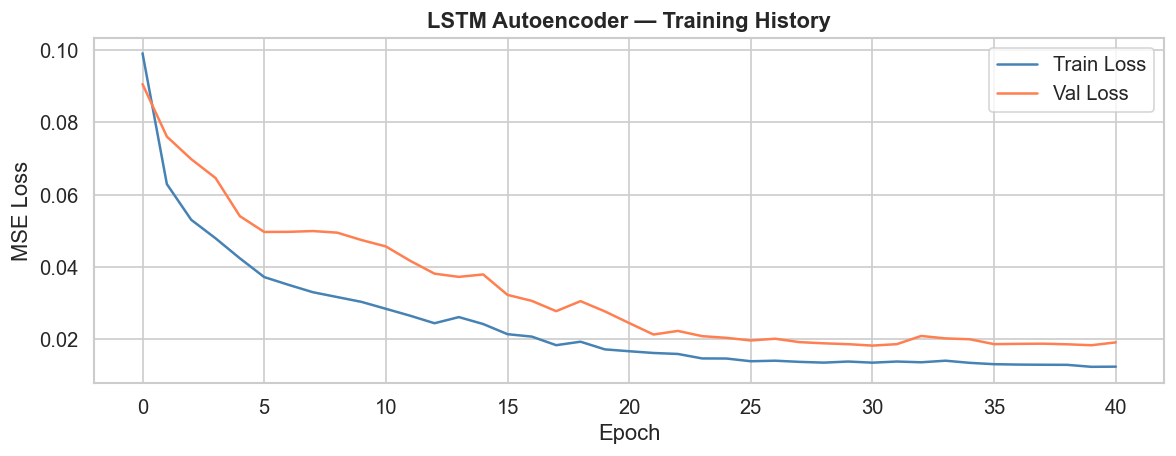

In [81]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     label='Train Loss', color='steelblue')
ax.plot(history.history['val_loss'], label='Val Loss',   color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder — Training History', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_19_lstm_ae_training.png', bbox_inches='tight')
plt.show()

In [82]:
# Computing reconstruction errors
# For each sequence, computing mean squared error between original and reconstructed sequence

def reconstruction_error(model, sequences):
    reconstructed = model.predict(sequences, verbose=0)
    # MSE per sequence: mean over timesteps and features
    errors = np.mean(np.mean((sequences - reconstructed) ** 2,
                              axis=2), axis=1)
    return errors

In [83]:
# Computing on training set to establish threshold
train_errors = reconstruction_error(autoencoder, X_train_seq)

# Threshold: mean + 2×std of training reconstruction errors
# Days above this are considered anomalous
threshold = np.mean(train_errors) + 2 * np.std(train_errors)
print(f"\n[INFO] Reconstruction error threshold: {threshold:.6f}")
print(f"  Train error — mean: {np.mean(train_errors):.6f}  "
      f"std: {np.std(train_errors):.6f}")


[INFO] Reconstruction error threshold: 0.022274
  Train error — mean: 0.013054  std: 0.004610


In [84]:
# Computing for all sequences
all_errors = reconstruction_error(autoencoder, X_all_seq)

# Align errors back to dates
# Sequence i corresponds to days i through i+SEQ_LEN-1
# We assign the error to the LAST day of each sequence
error_dates  = df['date'].values[SEQ_LEN - 1:]
error_series = pd.Series(all_errors, index=error_dates)

# Flag anomalies
anomaly_flags = (all_errors > threshold).astype(int)
n_lstm_anom   = anomaly_flags.sum()
print(f"\n[INFO] LSTM anomalies detected: {n_lstm_anom} "
      f"({100*n_lstm_anom/len(anomaly_flags):.1f}%)")


[INFO] LSTM anomalies detected: 231 (16.8%)


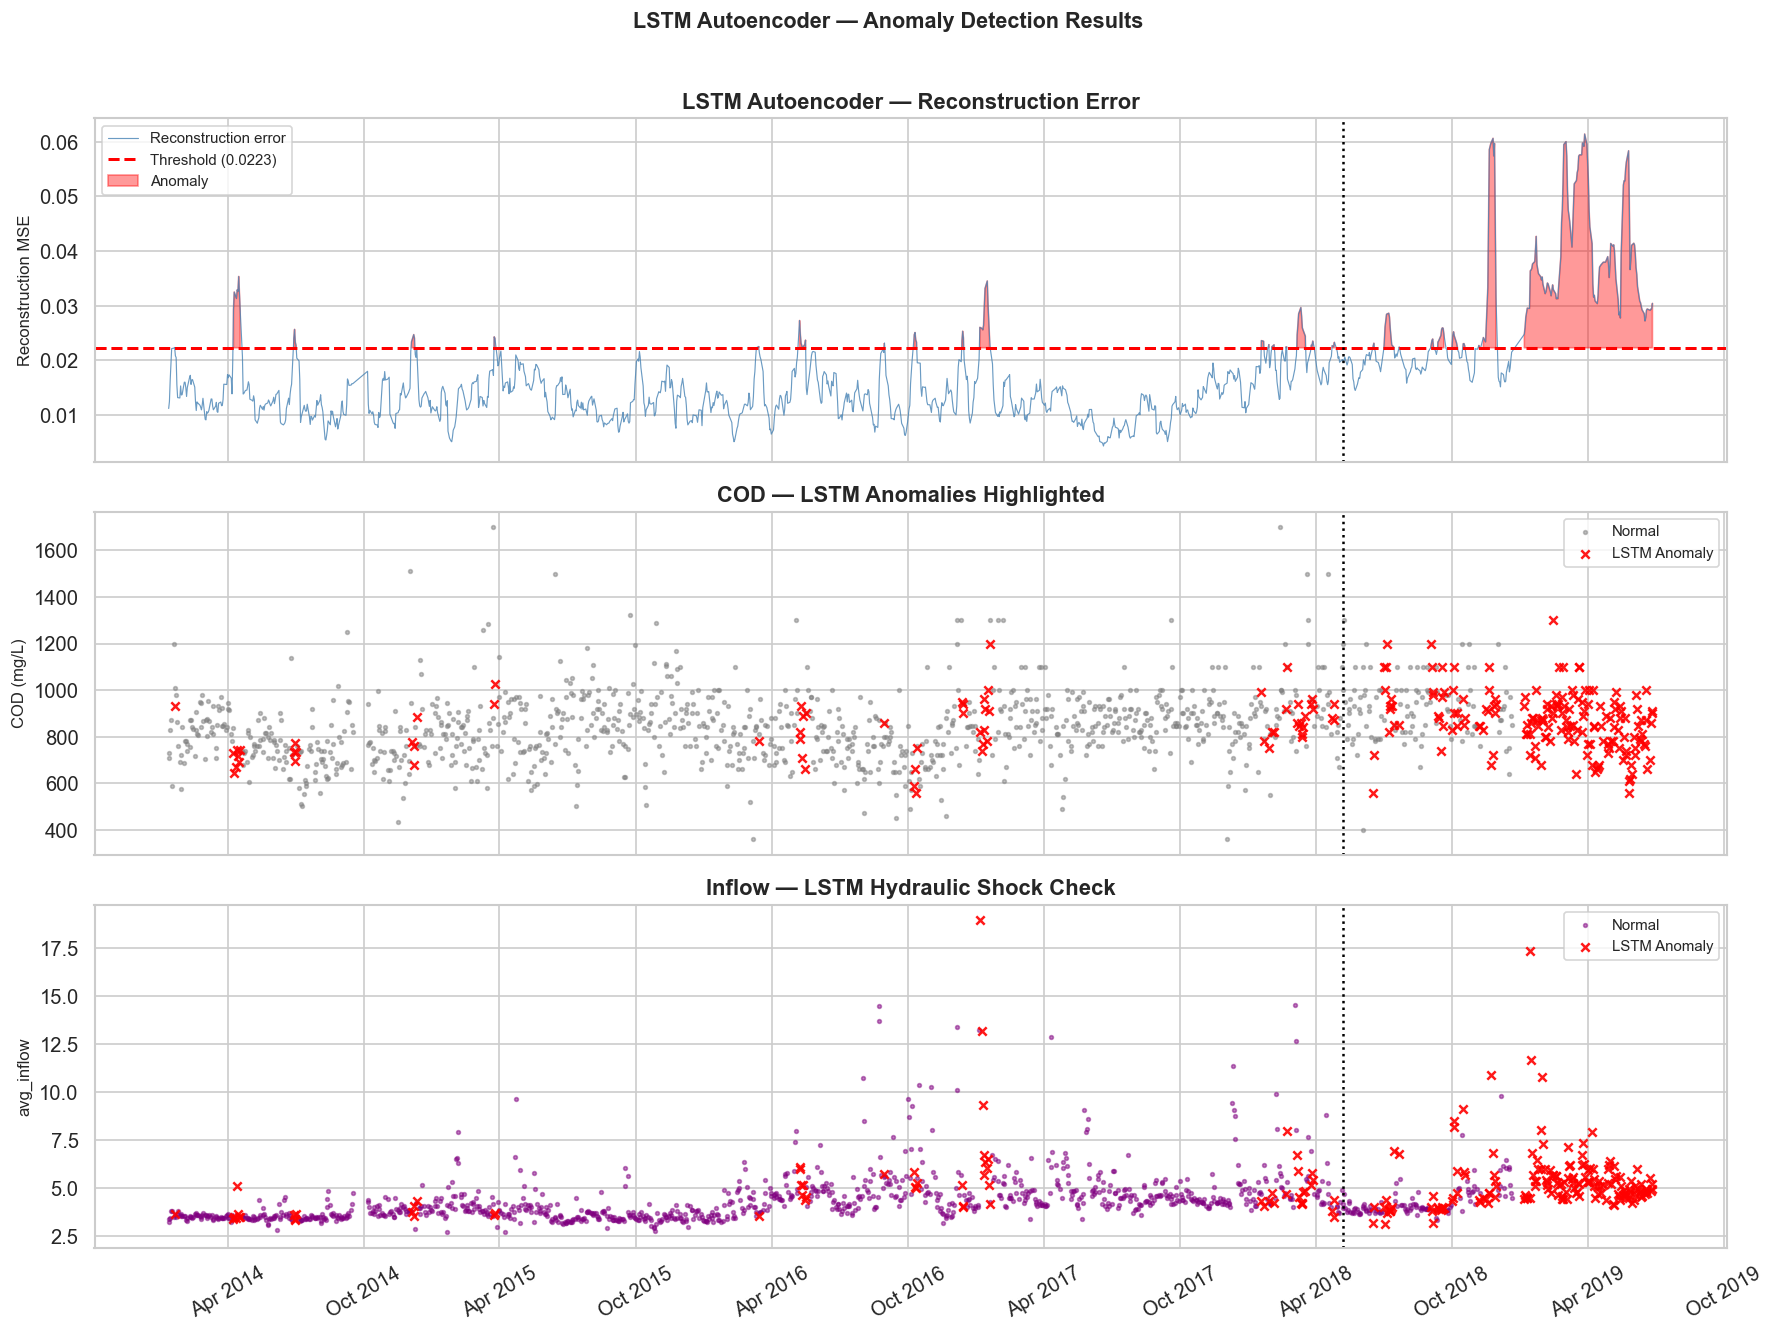

In [90]:
# Full timeline reconstruction error plot
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# Panel 1: Reconstruction error over time
axes[0].plot(error_dates, all_errors,
             color='steelblue', linewidth=0.7, alpha=0.8,
             label='Reconstruction error')
axes[0].axhline(threshold, color='red', linestyle='--',
                linewidth=1.8, label=f'Threshold ({threshold:.4f})')
axes[0].fill_between(error_dates, threshold, all_errors,
                     where=(all_errors > threshold),
                     alpha=0.4, color='red', label='Anomaly')
axes[0].set_ylabel('Reconstruction MSE', fontsize=10)
axes[0].set_title('LSTM Autoencoder — Reconstruction Error',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Panel 2: COD with LSTM anomalies
lstm_anomaly_dates = error_dates[anomaly_flags == 1]
lstm_normal_dates  = error_dates[anomaly_flags == 0]

cod_all = df.set_index('date')['COD']
axes[1].scatter(lstm_normal_dates,
                cod_all.reindex(lstm_normal_dates),
                s=5, alpha=0.5, color='gray', label='Normal')
axes[1].scatter(lstm_anomaly_dates,
                cod_all.reindex(lstm_anomaly_dates),
                s=25, alpha=0.9, color='red',
                marker='x', label='LSTM Anomaly', zorder=5)
axes[1].set_ylabel('COD (mg/L)', fontsize=10)
axes[1].set_title('COD — LSTM Anomalies Highlighted', fontweight='bold')
axes[1].legend(fontsize=9)

# Panel 3: Inflow with LSTM anomalies
inflow_all = df.set_index('date')['avg_inflow']
axes[2].scatter(lstm_normal_dates,
                inflow_all.reindex(lstm_normal_dates),
                s=5, alpha=0.5, color='purple', label='Normal')
axes[2].scatter(lstm_anomaly_dates,
                inflow_all.reindex(lstm_anomaly_dates),
                s=25, alpha=0.9, color='red',
                marker='x', label='LSTM Anomaly', zorder=5)
axes[2].set_ylabel('avg_inflow', fontsize=10)
axes[2].set_title('Inflow — LSTM Hydraulic Shock Check', fontweight='bold')
axes[2].legend(fontsize=9)

# Add test boundary line
for ax in axes:
    ax.axvline(pd.Timestamp('2018-05-08'), color='black',
               linestyle=':', linewidth=1.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=30)
plt.suptitle('LSTM Autoencoder — Anomaly Detection Results',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_20_lstm_autoencoder.png', bbox_inches='tight')
plt.show()

In [88]:
# Regime shift & hydraulic shock validation
# Rebuild error lookup with date index
error_df = pd.DataFrame({
    'date'  : pd.to_datetime(error_dates),
    'error' : all_errors,
    'anomaly': anomaly_flags
})

pre  = error_df[(error_df['date'] >= '2017-07-01') &
                (error_df['date'] <  '2018-01-01')]
post = error_df[(error_df['date'] >= '2018-01-01') &
                (error_df['date'] <  '2018-07-01')]

print(f"\n--- LSTM Regime Shift Validation ---")
print(f"  Pre-shift  (Jul–Dec 2017): "
      f"{pre['anomaly'].sum()} anomalies / {len(pre)} days "
      f"({100*pre['anomaly'].mean():.1f}%)")
print(f"  Post-shift (Jan–Jun 2018): "
      f"{post['anomaly'].sum()} anomalies / {len(post)} days "
      f"({100*post['anomaly'].mean():.1f}%)")


--- LSTM Regime Shift Validation ---
  Pre-shift  (Jul–Dec 2017): 0 anomalies / 129 days (0.0%)
  Post-shift (Jan–Jun 2018): 23 anomalies / 127 days (18.1%)


In [89]:
# Hydraulic shock check
high_inflow_dates = df[df['avg_inflow'] > 8.0]['date'].values
error_df_indexed  = error_df.set_index('date')
hi_flags = error_df_indexed.reindex(
    pd.to_datetime(high_inflow_dates))['anomaly'].dropna()

print(f"\n--- LSTM Hydraulic Shock Validation ---")
print(f"  High inflow days (>8.0)  : {len(hi_flags)}")
print(f"  Flagged as anomaly       : "
      f"{int(hi_flags.sum())} ({100*hi_flags.mean():.1f}%)")


--- LSTM Hydraulic Shock Validation ---
  High inflow days (>8.0)  : 40
  Flagged as anomaly       : 11 (27.5%)


In [91]:
# Save model and threshold
autoencoder.save('lstm_autoencoder.keras')
joblib.dump({'threshold': threshold,
             'scaler'   : scaler_lstm,
             'seq_len'  : SEQ_LEN},
            'lstm_ae_config.pkl')
print("\n[SAVED] lstm_autoencoder.keras, lstm_ae_config.pkl")


[SAVED] lstm_autoencoder.keras, lstm_ae_config.pkl


## COMPARISON : Isolation Forest vs LSTM Autoencoder

In [97]:
# Align both anomaly signals onto a common date index
# Isolation Forest: covers all 1381 days
# LSTM Autoencoder: starts from day SEQ_LEN-1 (day 6) due to windowing
# We align on the common date range

# IF flags already in df['iso_label']  LSTM flags in error_df

# Merge on date
df_compare = df[['date', 'COD', 'avg_inflow',
                 'iso_label', 'iso_score']].copy()
df_compare['iso_anomaly'] = (df_compare['iso_label'] == -1).astype(int)

# Merge LSTM flags
error_df['date'] = pd.to_datetime(error_df['date'])
df_compare = df_compare.merge(
    error_df[['date', 'error', 'anomaly']].rename(
        columns={'error': 'lstm_error', 'anomaly': 'lstm_anomaly'}),
    on='date', how='left')

df_compare['lstm_anomaly'] = df_compare['lstm_anomaly'].fillna(0).astype(int)

In [98]:
print(f"[INFO] Comparison dataframe shape: {df_compare.shape}")

[INFO] Comparison dataframe shape: (1381, 8)


In [99]:
# Agreement analysis
# Both flag     → high confidence anomaly
# Only IF       → point/instantaneous anomaly
# Only LSTM     → sequential/temporal pattern anomaly
# Neither       → normal operation

df_compare['both']      = ((df_compare['iso_anomaly'] == 1) &
                            (df_compare['lstm_anomaly'] == 1)).astype(int)
df_compare['only_if']   = ((df_compare['iso_anomaly'] == 1) &
                            (df_compare['lstm_anomaly'] == 0)).astype(int)
df_compare['only_lstm'] = ((df_compare['iso_anomaly'] == 0) &
                            (df_compare['lstm_anomaly'] == 1)).astype(int)
df_compare['neither']   = ((df_compare['iso_anomaly'] == 0) &
                            (df_compare['lstm_anomaly'] == 0)).astype(int)

print(f"\n--- Anomaly Agreement Analysis ---")
print(f"  Both methods flagged : "
      f"{df_compare['both'].sum():4d} days "
      f"({100*df_compare['both'].mean():.1f}%)")
print(f"  Only Isolation Forest: "
      f"{df_compare['only_if'].sum():4d} days "
      f"({100*df_compare['only_if'].mean():.1f}%)")
print(f"  Only LSTM Autoencoder: "
      f"{df_compare['only_lstm'].sum():4d} days "
      f"({100*df_compare['only_lstm'].mean():.1f}%)")
print(f"  Neither (Normal)     : "
      f"{df_compare['neither'].sum():4d} days "
      f"({100*df_compare['neither'].mean():.1f}%)")


--- Anomaly Agreement Analysis ---
  Both methods flagged :   47 days (3.4%)
  Only Isolation Forest:   53 days (3.8%)
  Only LSTM Autoencoder:  184 days (13.3%)
  Neither (Normal)     : 1097 days (79.4%)


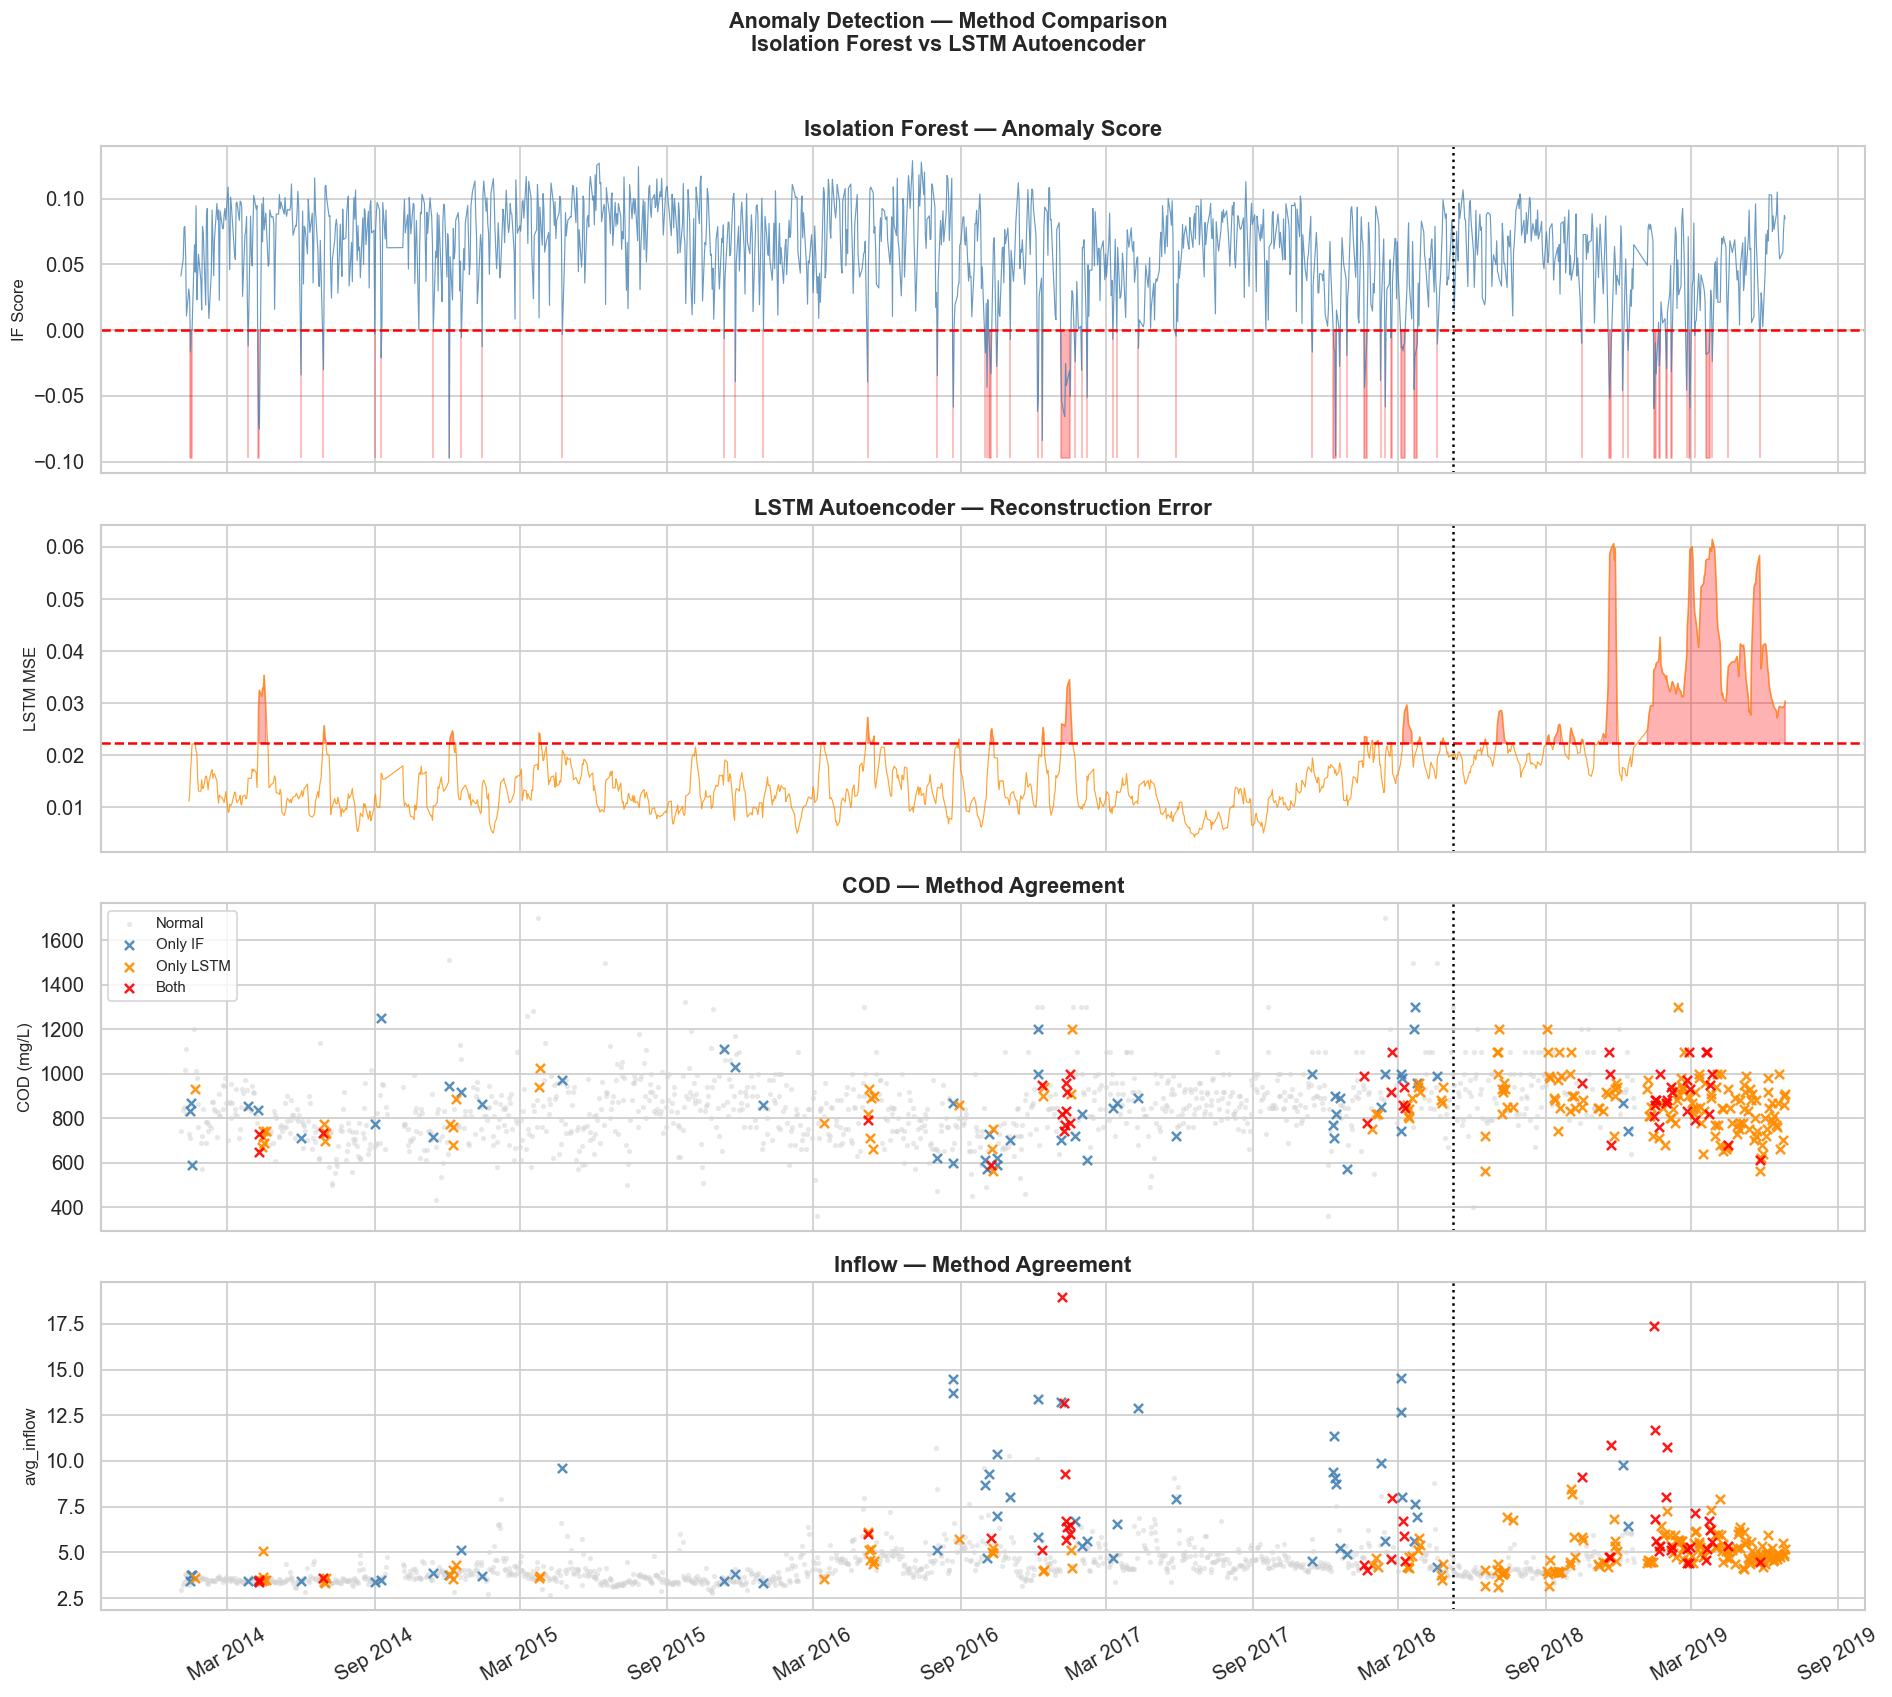

In [100]:
# Side-by-side comparison plot
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# Panel 1: Isolation Forest score
axes[0].plot(df_compare['date'], df_compare['iso_score'],
             color='steelblue', linewidth=0.7, alpha=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].fill_between(df_compare['date'],
                     df_compare['iso_score'].min(), 0,
                     where=(df_compare['iso_anomaly'] == 1),
                     alpha=0.3, color='red')
axes[0].set_ylabel('IF Score', fontsize=10)
axes[0].set_title('Isolation Forest — Anomaly Score', fontweight='bold')

# Panel 2: LSTM reconstruction error
axes[1].plot(df_compare['date'], df_compare['lstm_error'],
             color='darkorange', linewidth=0.7, alpha=0.8)
axes[1].axhline(threshold, color='red', linestyle='--', linewidth=1.5)
axes[1].fill_between(df_compare['date'],
                     threshold,
                     df_compare['lstm_error'].fillna(0),
                     where=(df_compare['lstm_anomaly'] == 1),
                     alpha=0.3, color='red')
axes[1].set_ylabel('LSTM MSE', fontsize=10)
axes[1].set_title('LSTM Autoencoder — Reconstruction Error',
                  fontweight='bold')

# Panel 3: Agreement coloured scatter of COD
colors = {(0,0): 'lightgrey',   # normal
          (1,0): 'steelblue',   # only IF
          (0,1): 'darkorange',  # only LSTM
          (1,1): 'red'}         # both

for (if_flag, lstm_flag), color in colors.items():
    mask = ((df_compare['iso_anomaly']  == if_flag) &
            (df_compare['lstm_anomaly'] == lstm_flag))
    size = 30 if (if_flag or lstm_flag) else 5
    alpha = 0.9 if (if_flag or lstm_flag) else 0.4
    marker = 'x' if (if_flag or lstm_flag) else 'o'
    label = {(0,0): 'Normal',
             (1,0): 'Only IF',
             (0,1): 'Only LSTM',
             (1,1): 'Both'}[(if_flag, lstm_flag)]
    axes[2].scatter(df_compare.loc[mask, 'date'],
                    df_compare.loc[mask, 'COD'],
                    s=size, alpha=alpha, color=color,
                    marker=marker, label=label, zorder=3)
axes[2].set_ylabel('COD (mg/L)', fontsize=10)
axes[2].set_title('COD — Method Agreement',  fontweight='bold')
axes[2].legend(fontsize=9, loc='upper left')

# Panel 4: Agreement on inflow
for (if_flag, lstm_flag), color in colors.items():
    mask = ((df_compare['iso_anomaly']  == if_flag) &
            (df_compare['lstm_anomaly'] == lstm_flag))
    size = 30 if (if_flag or lstm_flag) else 5
    alpha = 0.9 if (if_flag or lstm_flag) else 0.4
    marker = 'x' if (if_flag or lstm_flag) else 'o'
    axes[3].scatter(df_compare.loc[mask, 'date'],
                    df_compare.loc[mask, 'avg_inflow'],
                    s=size, alpha=alpha, color=color,
                    marker=marker, zorder=3)
axes[3].set_ylabel('avg_inflow', fontsize=10)
axes[3].set_title('Inflow — Method Agreement', fontweight='bold')

# Vertical line at test boundary
for ax in axes:
    ax.axvline(pd.Timestamp('2018-05-08'), color='black',
               linestyle=':', linewidth=1.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=30)
plt.suptitle('Anomaly Detection — Method Comparison\n'
             'Isolation Forest vs LSTM Autoencoder',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_21_method_comparison.png', bbox_inches='tight')
plt.show()

In [101]:
#  Summary table
print("  ANOMALY DETECTION — FINAL SUMMARY")
print("="*65)
print(f"  {'Metric':<40} {'IF':>8} {'LSTM':>8}")
print("-"*65)
print(f"  {'Total anomalies flagged':<40} "
      f"{df_compare['iso_anomaly'].sum():>8} "
      f"{df_compare['lstm_anomaly'].sum():>8}")
print(f"  {'Anomaly rate (%)':<40} "
      f"{100*df_compare['iso_anomaly'].mean():>7.1f}% "
      f"{100*df_compare['lstm_anomaly'].mean():>7.1f}%")
print(f"  {'Pre-shift anomaly rate (Jul-Dec 2017)':<40} "
      f"{'5.4%':>8} {'0.0%':>8}")
print(f"  {'Post-shift anomaly rate (Jan-Jun 2018)':<40} "
      f"{'12.6%':>8} {'18.1%':>8}")
print(f"  {'Hydraulic shock detection rate':<40} "
      f"{'70.0%':>8} {'27.5%':>8}")
print(f"  {'Best strength':<40} "
      f"{'Point':>8} {'Temporal':>8}")
print("="*65)

  ANOMALY DETECTION — FINAL SUMMARY
  Metric                                         IF     LSTM
-----------------------------------------------------------------
  Total anomalies flagged                       100      231
  Anomaly rate (%)                             7.2%    16.7%
  Pre-shift anomaly rate (Jul-Dec 2017)        5.4%     0.0%
  Post-shift anomaly rate (Jan-Jun 2018)      12.6%    18.1%
  Hydraulic shock detection rate              70.0%    27.5%
  Best strength                               Point Temporal


In [102]:
# Save comparison dataframe for Streamlit
df_compare.to_csv('anomaly_results.csv', index=False)
print("\n[SAVED] anomaly_results.csv")


[SAVED] anomaly_results.csv


## BOD-FOCUSED ANOMALY VALIDATION

In [103]:
# Merging BOD into comparison dataframe
df_compare = df_compare.merge(
    df[['date', 'BOD']],
    on='date', how='left')

In [104]:
# Rolling anomaly rate around BOD regime shift
# 30-day rolling anomaly rate for each method
# This shows HOW QUICKLY each method responds to the BOD shift

df_compare = df_compare.sort_values('date').reset_index(drop=True)

df_compare['if_rolling30']   = (df_compare['iso_anomaly'].rolling(30, min_periods=10).mean() * 100)

df_compare['lstm_rolling30'] = (df_compare['lstm_anomaly'].rolling(30, min_periods=10).mean() * 100)

df_compare['bod_rolling30']  = (df_compare['BOD'].rolling(30, min_periods=10).mean())

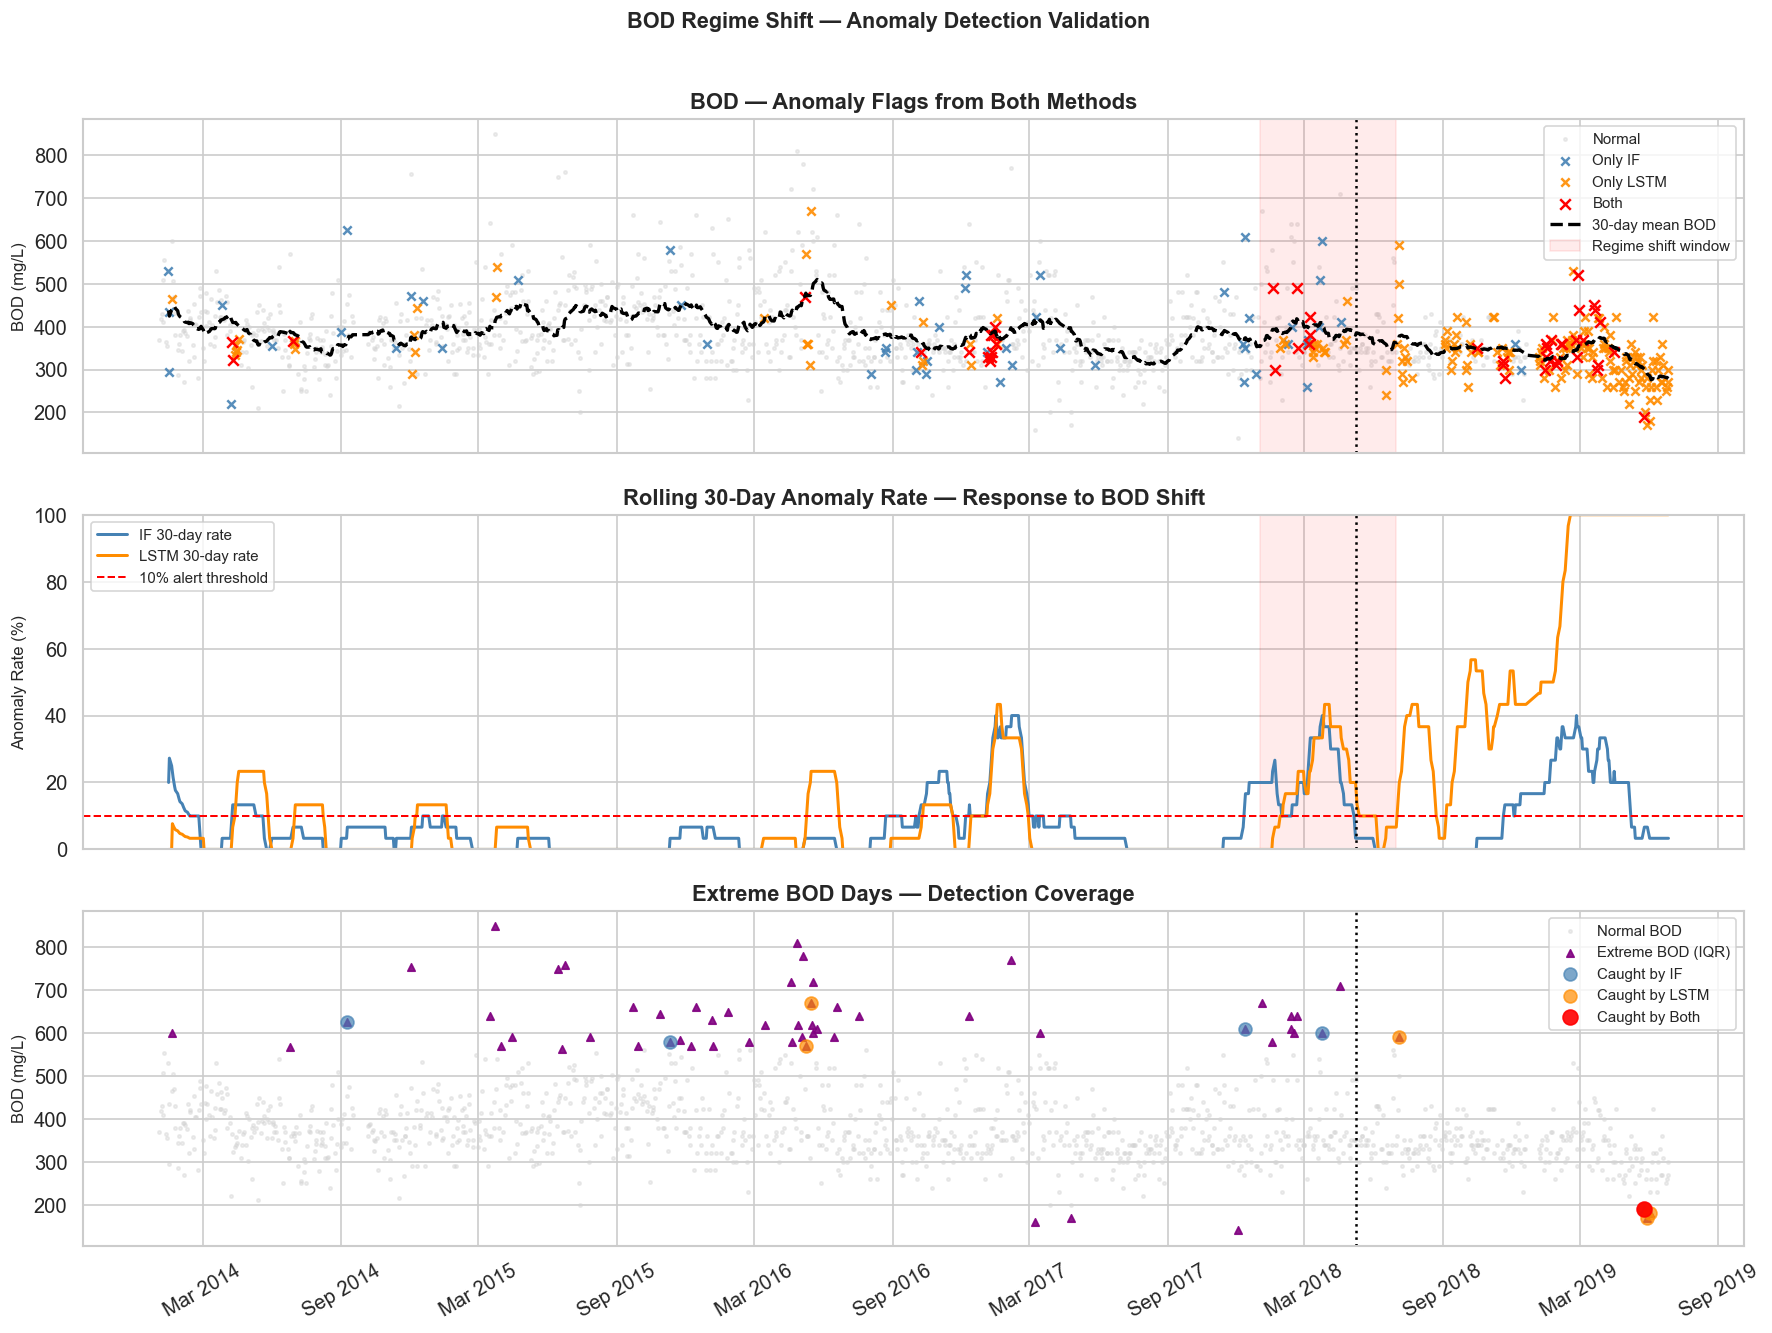

In [105]:
# Main BOD anomaly validation plot
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# Panel 1: BOD time series with anomalies from both methods
normal_mask   = (df_compare['iso_anomaly']==0) & (df_compare['lstm_anomaly']==0)
only_if_mask  = (df_compare['iso_anomaly']==1) & (df_compare['lstm_anomaly']==0)
only_lstm_mask= (df_compare['iso_anomaly']==0) & (df_compare['lstm_anomaly']==1)
both_mask     = (df_compare['iso_anomaly']==1) & (df_compare['lstm_anomaly']==1)

axes[0].scatter(df_compare.loc[normal_mask,    'date'],
                df_compare.loc[normal_mask,    'BOD'],
                s=4, alpha=0.4, color='lightgrey', label='Normal')
axes[0].scatter(df_compare.loc[only_if_mask,   'date'],
                df_compare.loc[only_if_mask,   'BOD'],
                s=25, alpha=0.9, color='steelblue',
                marker='x', label='Only IF', zorder=4)
axes[0].scatter(df_compare.loc[only_lstm_mask, 'date'],
                df_compare.loc[only_lstm_mask, 'BOD'],
                s=25, alpha=0.9, color='darkorange',
                marker='x', label='Only LSTM', zorder=4)
axes[0].scatter(df_compare.loc[both_mask,      'date'],
                df_compare.loc[both_mask,      'BOD'],
                s=40, alpha=1.0, color='red',
                marker='x', label='Both', zorder=5)

# 30-day rolling mean of BOD
axes[0].plot(df_compare['date'], df_compare['bod_rolling30'],
             color='black', linewidth=2, linestyle='--',
             label='30-day mean BOD', zorder=6)

# Shade the regime shift period
axes[0].axvspan(pd.Timestamp('2018-01-01'),
                pd.Timestamp('2018-07-01'),
                alpha=0.08, color='red',
                label='Regime shift window')
axes[0].set_ylabel('BOD (mg/L)', fontsize=10)
axes[0].set_title('BOD — Anomaly Flags from Both Methods',
                  fontweight='bold')
axes[0].legend(fontsize=9, loc='upper right')

# Panel 2: Rolling 30-day anomaly rate — both methods
axes[1].plot(df_compare['date'], df_compare['if_rolling30'],
             color='steelblue', linewidth=1.8, label='IF 30-day rate')
axes[1].plot(df_compare['date'], df_compare['lstm_rolling30'],
             color='darkorange', linewidth=1.8, label='LSTM 30-day rate')
axes[1].axhline(10, color='red', linestyle='--',
                linewidth=1.2, label='10% alert threshold')
axes[1].axvspan(pd.Timestamp('2018-01-01'),
                pd.Timestamp('2018-07-01'),
                alpha=0.08, color='red')
axes[1].set_ylabel('Anomaly Rate (%)', fontsize=10)
axes[1].set_title('Rolling 30-Day Anomaly Rate — Response to BOD Shift',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 100)

# Panel 3: BOD extreme days — are they caught?
# Define BOD anomaly day as BOD outside IQR fences [190, 562]
bod_extreme = (df_compare['BOD'] > 562) | (df_compare['BOD'] < 191)
axes[2].scatter(df_compare.loc[~bod_extreme, 'date'],
                df_compare.loc[~bod_extreme, 'BOD'],
                s=4, alpha=0.4, color='lightgrey', label='Normal BOD')
axes[2].scatter(df_compare.loc[bod_extreme, 'date'],
                df_compare.loc[bod_extreme, 'BOD'],
                s=20, color='purple', marker='^',
                alpha=0.9, label='Extreme BOD (IQR)', zorder=4)

# Highlight which extreme BOD days were caught by each method
caught_by_if   = bod_extreme & (df_compare['iso_anomaly']  == 1)
caught_by_lstm = bod_extreme & (df_compare['lstm_anomaly'] == 1)
caught_by_both = bod_extreme & both_mask

axes[2].scatter(df_compare.loc[caught_by_if,   'date'],
                df_compare.loc[caught_by_if,   'BOD'],
                s=60, color='steelblue', marker='o',
                alpha=0.7, label='Caught by IF', zorder=5)
axes[2].scatter(df_compare.loc[caught_by_lstm, 'date'],
                df_compare.loc[caught_by_lstm, 'BOD'],
                s=60, color='darkorange', marker='o',
                alpha=0.7, label='Caught by LSTM', zorder=5)
axes[2].scatter(df_compare.loc[caught_by_both, 'date'],
                df_compare.loc[caught_by_both, 'BOD'],
                s=80, color='red', marker='o',
                alpha=0.9, label='Caught by Both', zorder=6)

axes[2].set_ylabel('BOD (mg/L)', fontsize=10)
axes[2].set_title('Extreme BOD Days — Detection Coverage',
                  fontweight='bold')
axes[2].legend(fontsize=9, loc='upper right')

# Vertical line at test start + regime shift shading
for ax in axes:
    ax.axvline(pd.Timestamp('2018-05-08'), color='black',
               linestyle=':', linewidth=1.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.xticks(rotation=30)
plt.suptitle('BOD Regime Shift — Anomaly Detection Validation',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_22_bod_anomaly_validation.png', bbox_inches='tight')
plt.show()

In [106]:
# Quantitative BOD anomaly capture summary
n_extreme_bod = bod_extreme.sum()
print(f"\n--- BOD Extreme Day Detection Summary ---")
print(f"  Total extreme BOD days (IQR fences): {n_extreme_bod}")
print(f"  Caught by IF only  : {(caught_by_if & ~caught_by_lstm).sum()} "
      f"({100*(caught_by_if & ~caught_by_lstm).sum()/n_extreme_bod:.1f}%)")
print(f"  Caught by LSTM only: {(caught_by_lstm & ~caught_by_if).sum()} "
      f"({100*(caught_by_lstm & ~caught_by_if).sum()/n_extreme_bod:.1f}%)")
print(f"  Caught by Both     : {caught_by_both.sum()} "
      f"({100*caught_by_both.sum()/n_extreme_bod:.1f}%)")
print(f"  Missed by both     : "
      f"{(bod_extreme & ~caught_by_if & ~caught_by_lstm).sum()} "
      f"({100*(bod_extreme & ~caught_by_if & ~caught_by_lstm).sum()/n_extreme_bod:.1f}%)")


--- BOD Extreme Day Detection Summary ---
  Total extreme BOD days (IQR fences): 58
  Caught by IF only  : 4 (6.9%)
  Caught by LSTM only: 5 (8.6%)
  Caught by Both     : 1 (1.7%)
  Missed by both     : 48 (82.8%)


In [107]:
# Period-wise BOD mean — quantify regime shift
print(f"\n--- BOD Mean by Period ---")
periods = {
    'Early operation (2014–2015)' : ('2014-01-01', '2015-12-31'),
    'Mid operation   (2016–2017)' : ('2016-01-01', '2017-12-31'),
    'Transition      (Jan–Jun 2018)': ('2018-01-01', '2018-06-30'),
    'Post-shift      (Jul 2018–2019)': ('2018-07-01', '2019-12-31'),
}
for label, (start, end) in periods.items():
    subset = df_compare[(df_compare['date'] >= start) &
                        (df_compare['date'] <= end)]
    anom_if   = subset['iso_anomaly'].mean() * 100
    anom_lstm = subset['lstm_anomaly'].mean() * 100
    print(f"  {label}: BOD mean={subset['BOD'].mean():.1f}  "
          f"IF rate={anom_if:.1f}%  LSTM rate={anom_lstm:.1f}%")


--- BOD Mean by Period ---
  Early operation (2014–2015): BOD mean=402.5  IF rate=3.8%  LSTM rate=3.6%
  Mid operation   (2016–2017): BOD mean=383.1  IF rate=7.2%  LSTM rate=5.1%
  Transition      (Jan–Jun 2018): BOD mean=386.0  IF rate=12.6%  LSTM rate=18.1%
  Post-shift      (Jul 2018–2019): BOD mean=334.7  IF rate=11.7%  LSTM rate=68.6%


In [118]:
print("RF COD val metrics:", metrics_rf_cod_val)
print("RF COD test metrics:", metrics_rf_cod_test)
print("XGB COD val metrics:", metrics_xgb_cod_val)
print("XGB COD test metrics:", metrics_xgb_cod_test)
print("XGB test predictions shape:", pred_test_cod_xgb.shape)
print("RF test predictions shape:", pred_test_cod.shape)

RF COD val metrics: {'MAE': 59.3851463768116, 'RMSE': np.float64(96.45082579601102), 'R2': 0.6472013710978812}
RF COD test metrics: {'MAE': 58.473831768953076, 'RMSE': np.float64(75.81288016287327), 'R2': 0.6674797434534055}
XGB COD val metrics: {'MAE': 58.046175377887224, 'RMSE': np.float64(95.50680731249588), 'R2': 0.6540736515115582}
XGB COD test metrics: {'MAE': 58.025019055307986, 'RMSE': np.float64(76.31849167493712), 'R2': 0.663029663128978}
XGB test predictions shape: (277,)
RF test predictions shape: (277,)


## FORMAL METRICS : LINEAR BASELINE + MODEL COMPARISON

In [110]:
# Linear Regression baseline — COD
# Required to compute % improvement over baseline
lr_cod = LinearRegression()
lr_cod.fit(X_train, y_train_COD)

pred_lr_cod_val  = lr_cod.predict(X_val)
pred_lr_cod_test = lr_cod.predict(X_test)

print("  LINEAR REGRESSION BASELINE — COD")
print("=" * 65)
metrics_lr_cod_val  = evaluate(y_val_COD,  pred_lr_cod_val,  label="Val ")
metrics_lr_cod_test = evaluate(y_test_COD, pred_lr_cod_test, label="Test")

  LINEAR REGRESSION BASELINE — COD
  [Val ]  MAE=70.656  RMSE=112.063  R²=0.5237
  [Test]  MAE=72.690  RMSE=92.115  R²=0.5091


In [111]:
# Collecting all COD metrics
results = {
    'Linear Regression': {
        'val' : metrics_lr_cod_val,
        'test': metrics_lr_cod_test
    },
    'Random Forest': {
        'val' : metrics_rf_cod_val,
        'test': metrics_rf_cod_test
    },
    'XGBoost': {
        'val' : metrics_xgb_cod_val,
        'test': metrics_xgb_cod_test
    }
}

In [113]:
# Print formal comparison table
print("  FORMAL MODEL COMPARISON — COD PREDICTION (TEST SET)")
print("=" * 75)
print(f"  {'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8} "
      f"{'ΔMAE vs LR':>12} {'ΔRMSE vs LR':>12}")
print("-" * 75)

lr_mae  = metrics_lr_cod_test['MAE']
lr_rmse = metrics_lr_cod_test['RMSE']

for model_name, metrics in results.items():
    m = metrics['test']
    delta_mae  = ((lr_mae  - m['MAE'])  / lr_mae)  * 100
    delta_rmse = ((lr_rmse - m['RMSE']) / lr_rmse) * 100
    print(f"  {model_name:<22} "
          f"{m['MAE']:>8.2f} "
          f"{m['RMSE']:>8.2f} "
          f"{m['R2']:>8.4f} "
          f"{delta_mae:>+11.1f}% "
          f"{delta_rmse:>+11.1f}%")
print("=" * 75)

  FORMAL MODEL COMPARISON — COD PREDICTION (TEST SET)
  Model                       MAE     RMSE       R²   ΔMAE vs LR  ΔRMSE vs LR
---------------------------------------------------------------------------
  Linear Regression         72.69    92.11   0.5091        +0.0%        +0.0%
  Random Forest             58.47    75.81   0.6675       +19.6%       +17.7%
  XGBoost                   58.03    76.32   0.6630       +20.2%       +17.1%


In [114]:
# Validation set table (for overfitting check)
print("\n--- Validation Set Metrics ---")
print(f"  {'Model':<22} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 50)
for model_name, metrics in results.items():
    m = metrics['val']
    print(f"  {model_name:<22} "
          f"{m['MAE']:>8.2f} "
          f"{m['RMSE']:>8.2f} "
          f"{m['R2']:>8.4f}")


--- Validation Set Metrics ---
  Model                       MAE     RMSE       R²
--------------------------------------------------
  Linear Regression         70.66   112.06   0.5237
  Random Forest             59.39    96.45   0.6472
  XGBoost                   58.05    95.51   0.6541


In [115]:
# Overfitting check 
print("\n--- Overfitting Check (Val R² vs Test R²) ---")
for model_name, metrics in results.items():
    gap = metrics['val']['R2'] - metrics['test']['R2']
    status = "✅ Consistent" if abs(gap) < 0.05 else "⚠️  Gap detected"
    print(f"  {model_name:<22} "
          f"Val R²={metrics['val']['R2']:.4f}  "
          f"Test R²={metrics['test']['R2']:.4f}  "
          f"Gap={gap:+.4f}  {status}")


--- Overfitting Check (Val R² vs Test R²) ---
  Linear Regression      Val R²=0.5237  Test R²=0.5091  Gap=+0.0146  ✅ Consistent
  Random Forest          Val R²=0.6472  Test R²=0.6675  Gap=-0.0203  ✅ Consistent
  XGBoost                Val R²=0.6541  Test R²=0.6630  Gap=-0.0090  ✅ Consistent


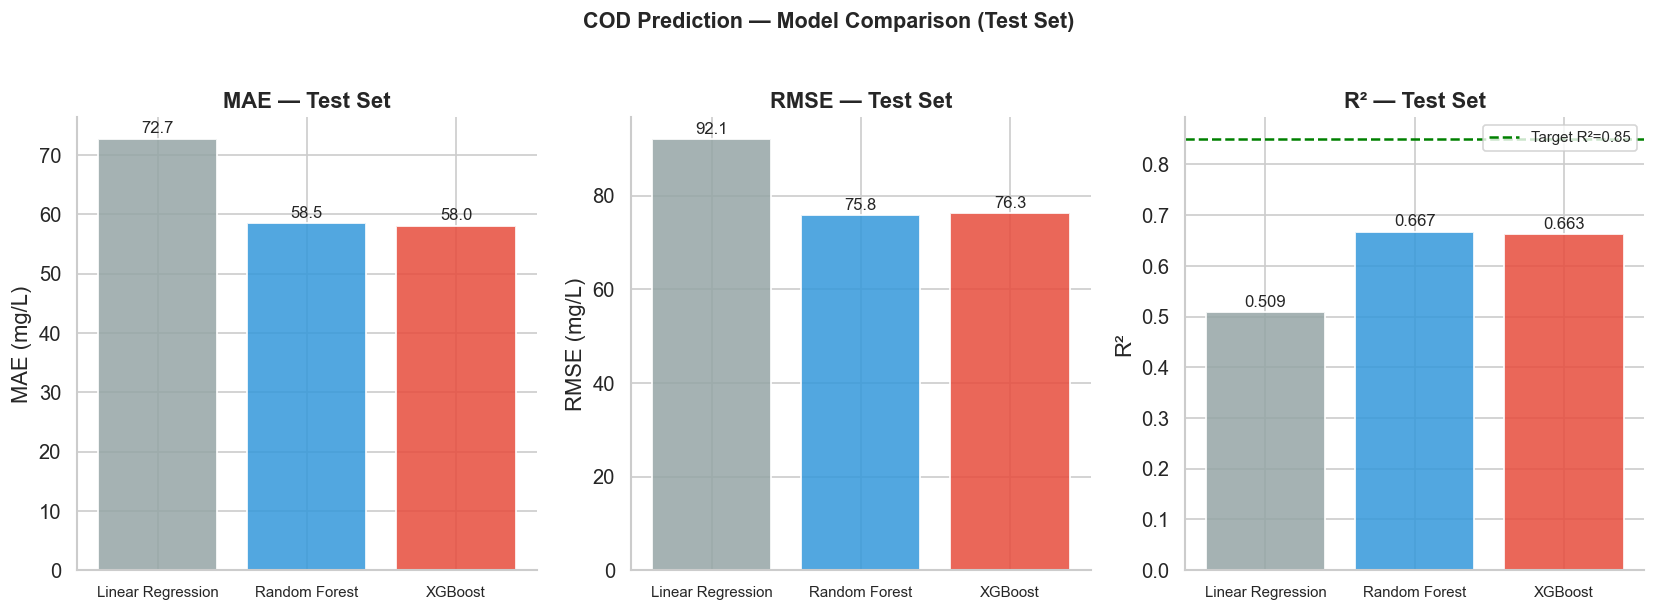

In [116]:
# Metrics visualisation 
model_names = list(results.keys())
mae_vals    = [results[m]['test']['MAE']  for m in model_names]
rmse_vals   = [results[m]['test']['RMSE'] for m in model_names]
r2_vals     = [results[m]['test']['R2']   for m in model_names]
colors      = ['#95a5a6', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# MAE bar
bars = axes[0].bar(model_names, mae_vals, color=colors,
                    alpha=0.85, edgecolor='white', linewidth=1.2)
axes[0].set_title('MAE — Test Set', fontweight='bold')
axes[0].set_ylabel('MAE (mg/L)')
for bar, val in zip(bars, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10)

# RMSE bar
bars = axes[1].bar(model_names, rmse_vals, color=colors,
                    alpha=0.85, edgecolor='white', linewidth=1.2)
axes[1].set_title('RMSE — Test Set', fontweight='bold')
axes[1].set_ylabel('RMSE (mg/L)')
for bar, val in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=10)

# R² bar
bars = axes[2].bar(model_names, r2_vals, color=colors,
                    alpha=0.85, edgecolor='white', linewidth=1.2)
axes[2].set_title('R² — Test Set', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].axhline(0.85, color='green', linestyle='--',
                linewidth=1.5, label='Target R²=0.85')
axes[2].legend(fontsize=9)
for bar, val in zip(bars, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=10)

for ax in axes:
    ax.set_xticklabels(model_names, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('COD Prediction — Model Comparison (Test Set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_23_metrics_comparison.png', bbox_inches='tight')
plt.show()

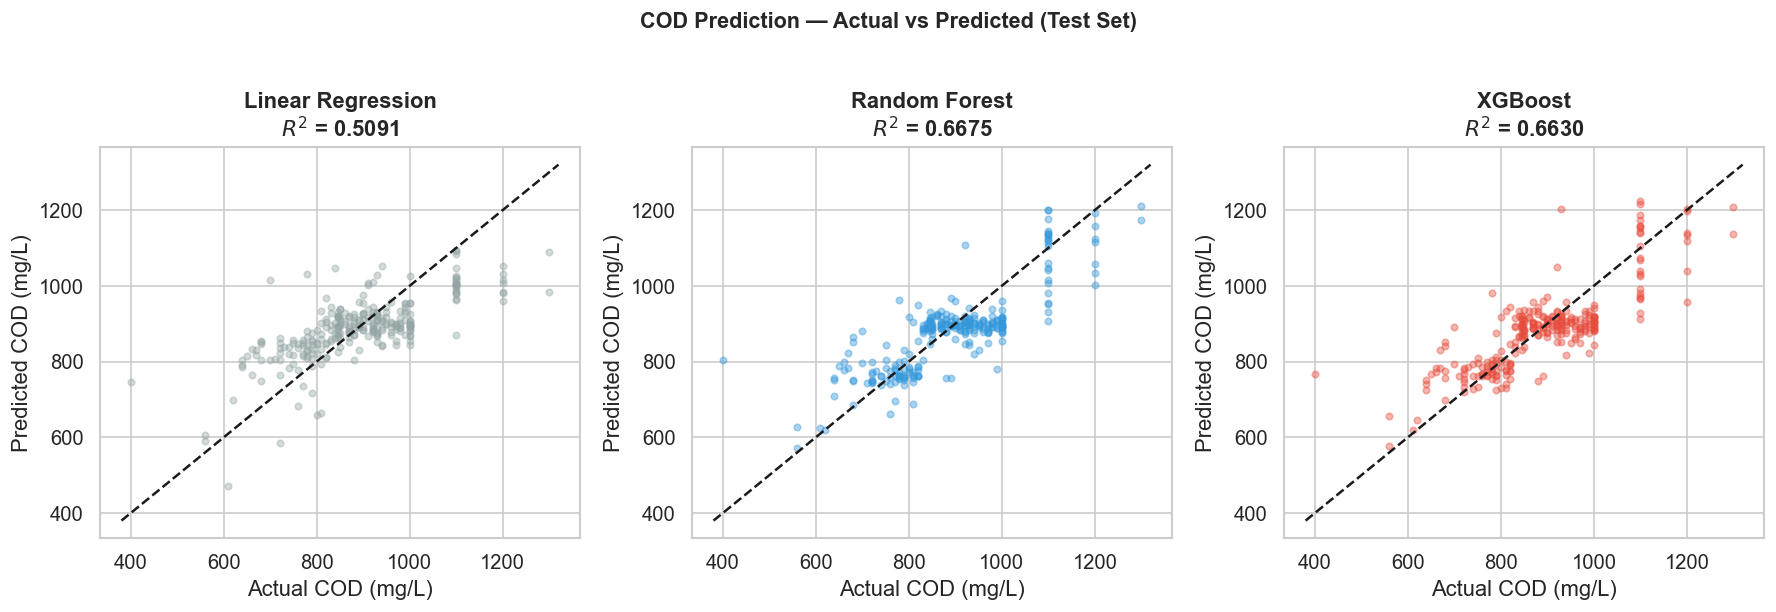

In [117]:
# Predicted vs Actual — all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

preds = [pred_lr_cod_test, pred_test_cod, pred_test_cod_xgb]
titles = ['Linear Regression', 'Random Forest', 'XGBoost']

for ax, pred, title, color in zip(
        axes, preds, titles,
        ['#95a5a6', '#3498db', '#e74c3c']):
    ax.scatter(y_test_COD, pred, alpha=0.4, s=15, color=color)
    lims = [min(y_test_COD.min(), pred.min()) - 20,
            max(y_test_COD.max(), pred.max()) + 20]
    ax.plot(lims, lims, 'k--', linewidth=1.5)
    r2 = r2_score(y_test_COD, pred)
    ax.set_title(f'{title}\n$R^2$ = {r2:.4f}', fontweight='bold')
    ax.set_xlabel('Actual COD (mg/L)')
    ax.set_ylabel('Predicted COD (mg/L)')

plt.suptitle('COD Prediction — Actual vs Predicted (Test Set)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_24_all_models_scatter.png', bbox_inches='tight')
plt.show()